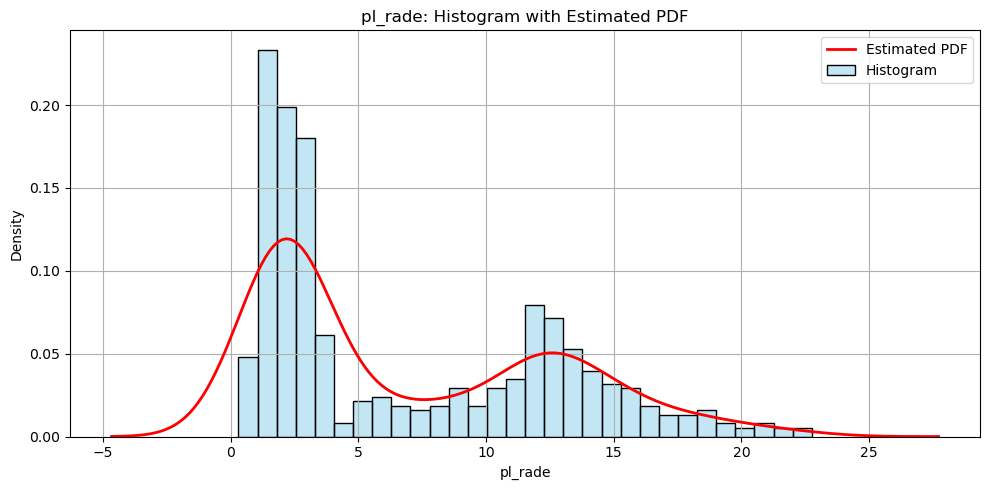

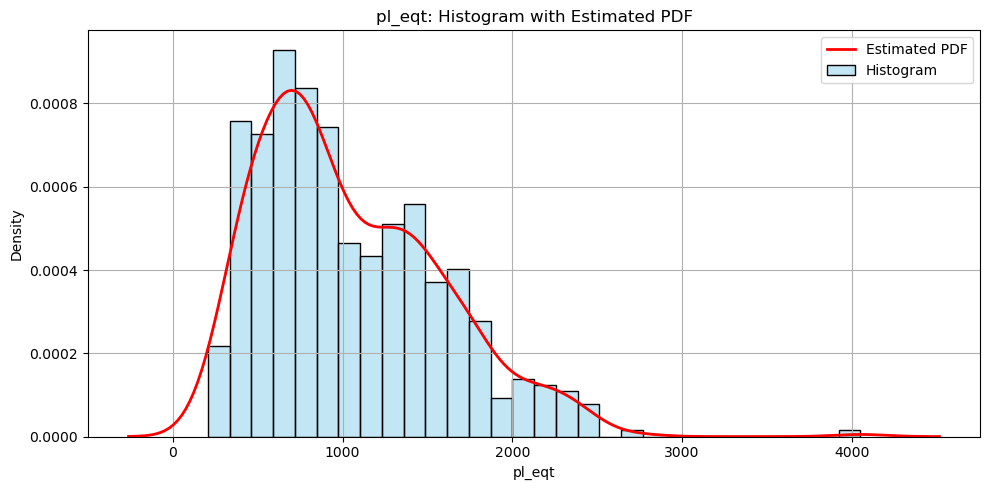

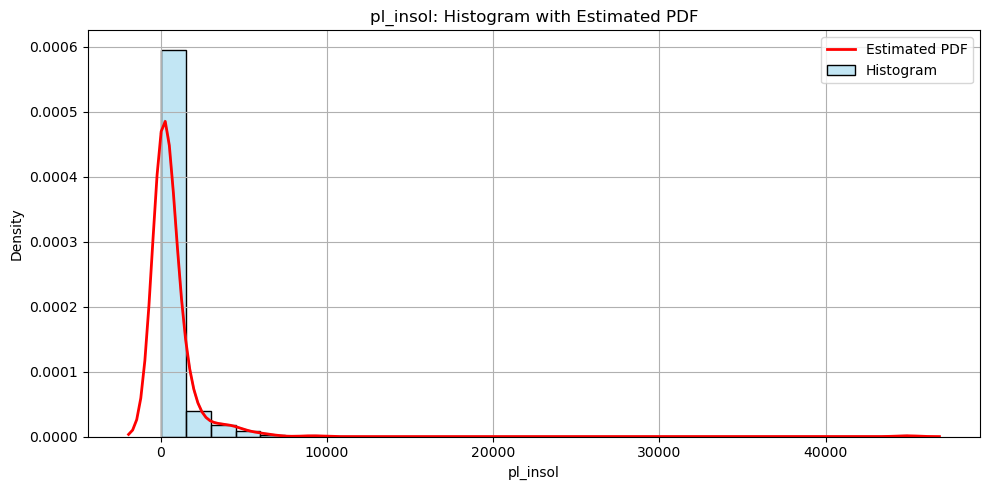

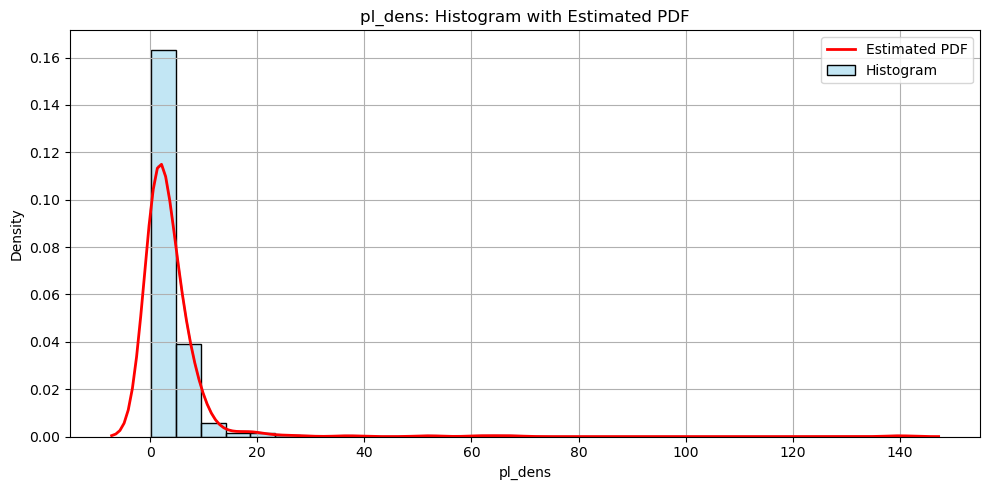

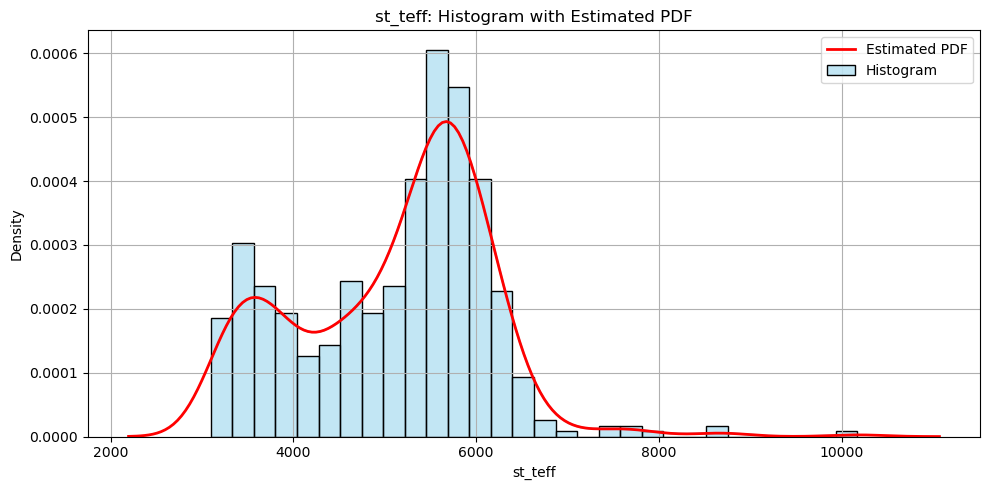

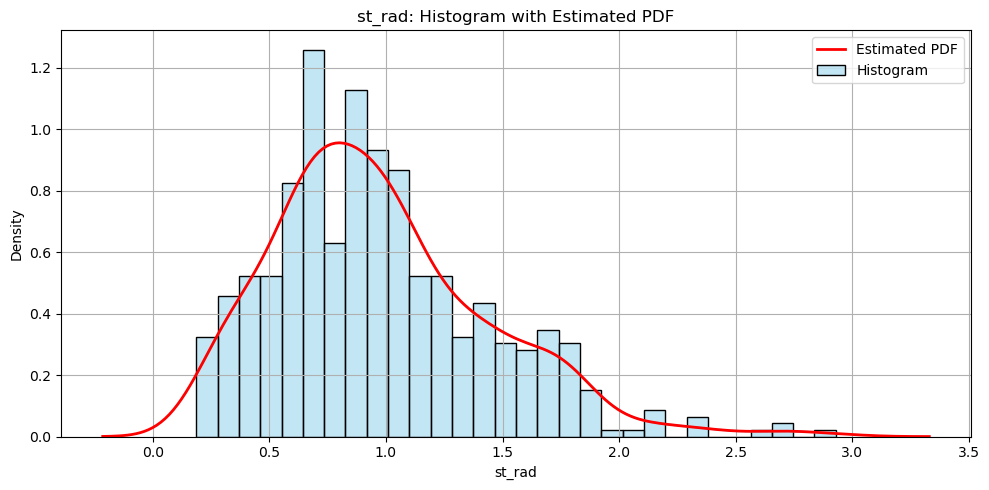

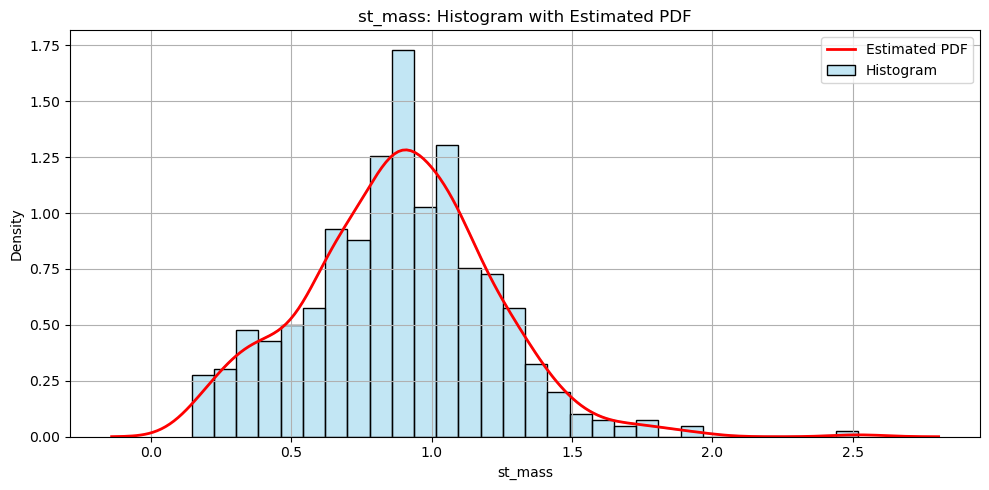

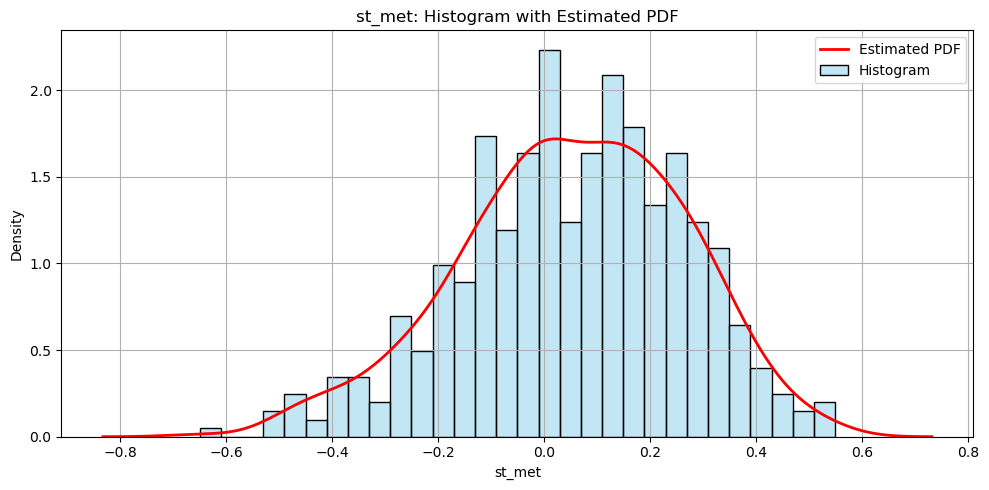

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from data_processing import load_and_prepare_data
import warnings

# Suppress warnings for cleaner plots
warnings.filterwarnings("ignore")

# ✅ Load the prepared dataset from your local project directory
df = load_and_prepare_data("Data/Planetary-Systems-May-20-2025_clean.csv")

# Check if the data was loaded
if df is None:
    raise RuntimeError("❌ Failed to load data. Check your path or preprocessing logic.")

# ✅ Define features relevant to habitability
features = ["pl_rade", "pl_eqt", "pl_insol", "pl_dens", "st_teff", "st_rad", "st_mass", "st_met"]

# ✅ Drop rows with missing values in those features
df_clean = df[features].dropna()

# ✅ Plot histogram + overlaid PDF for each feature
for col in features:
    plt.figure(figsize=(10, 5))
    
    # Histogram with KDE overlay
    sns.histplot(df_clean[col], kde=True, stat="density", bins=30, 
                 color="skyblue", edgecolor="black", label="Histogram")
    
    # Optional: show KDE line separately in red if you want more emphasis
    sns.kdeplot(df_clean[col], color="red", linewidth=2, label="Estimated PDF")

    plt.title(f"{col}: Histogram with Estimated PDF")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


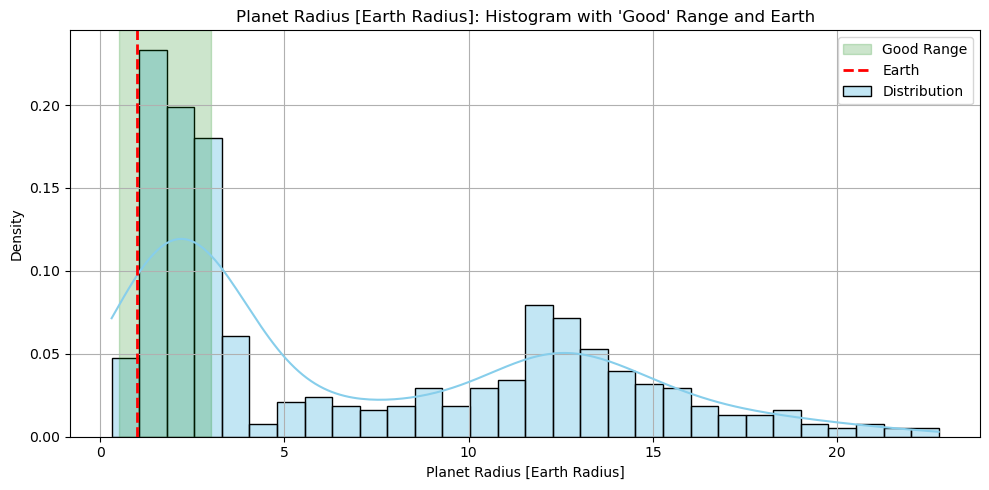

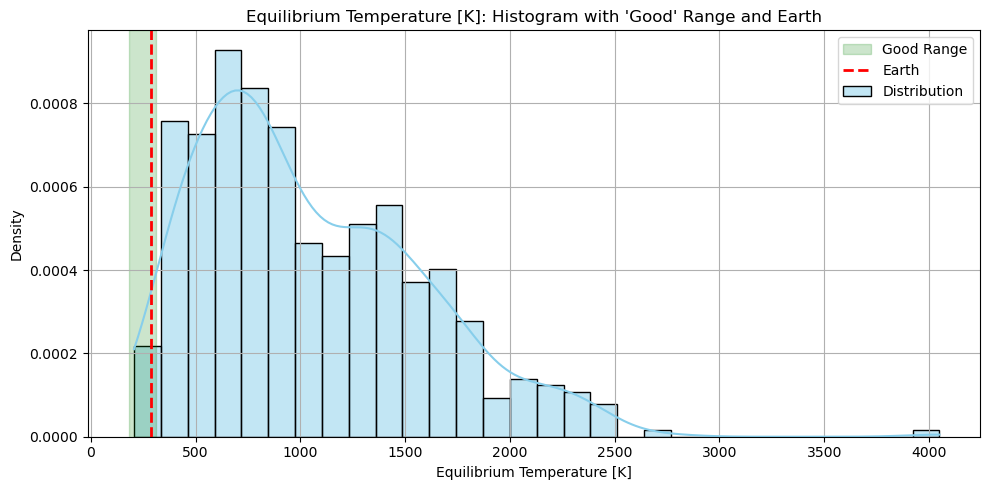

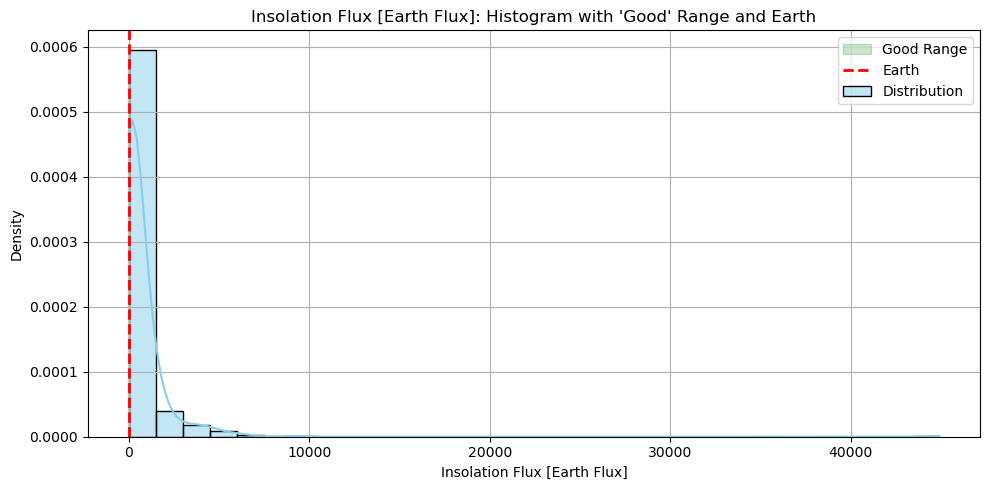

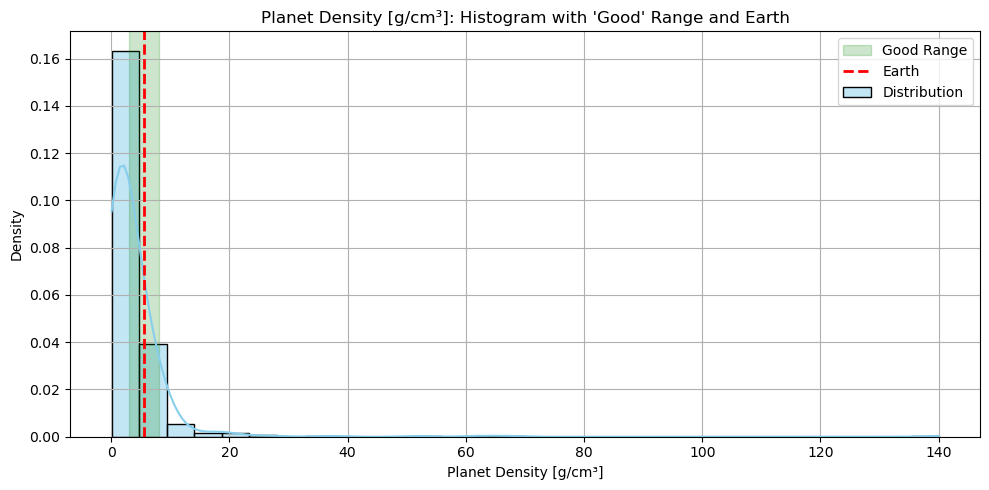

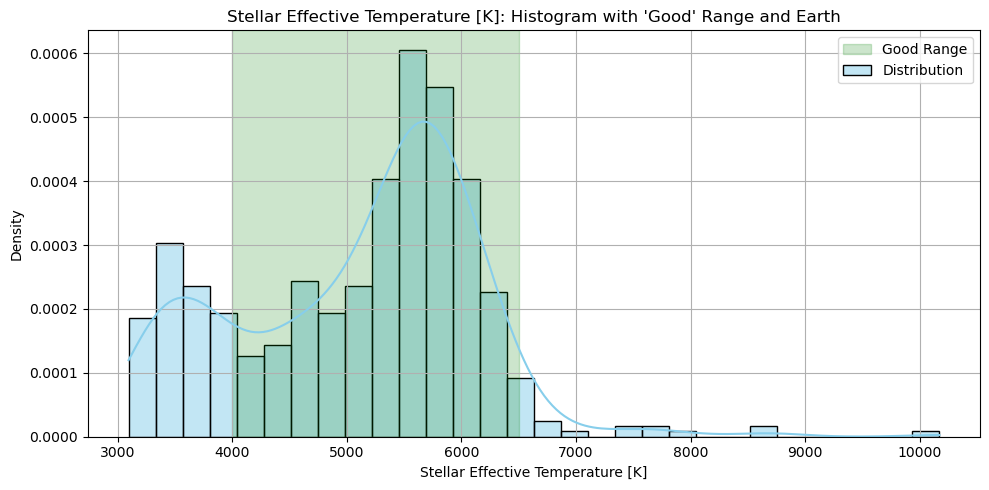

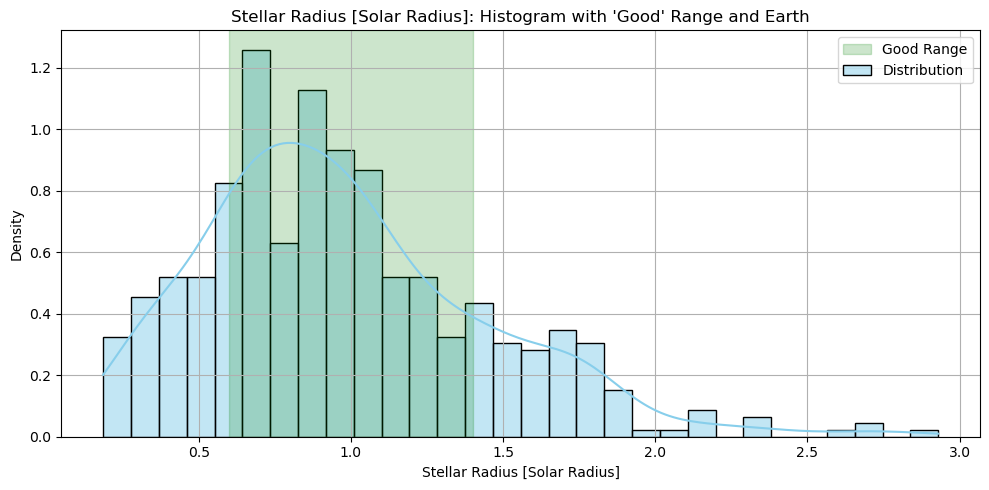

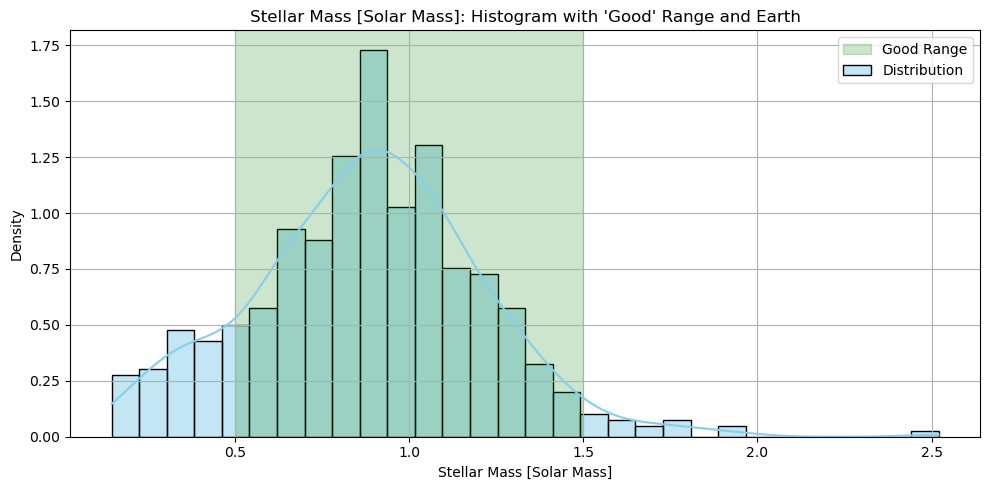

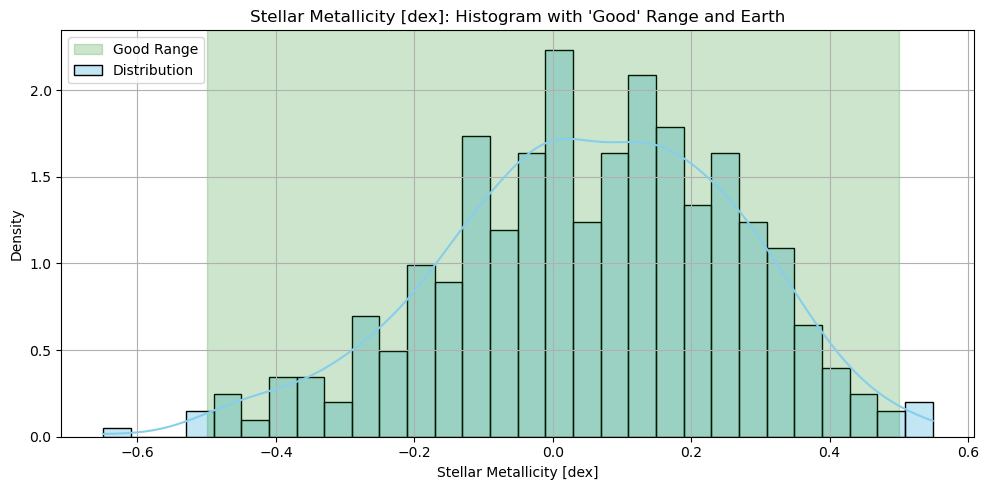

In [22]:
# Determine a notion of what is "good"
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from data_processing import load_and_prepare_data

# Load data
df = load_and_prepare_data("Data/Planetary-Systems-May-20-2025_clean.csv")
features = ["pl_rade", "pl_eqt", "pl_insol", "pl_dens", "st_teff", "st_rad", "st_mass", "st_met"]
df_clean = df[features].dropna()

# Labels for axis and titles
feature_labels = {
    "pl_rade": "Planet Radius [Earth Radius]",
    "pl_eqt": "Equilibrium Temperature [K]",
    "pl_insol": "Insolation Flux [Earth Flux]",
    "pl_dens": "Planet Density [g/cm³]",
    "st_teff": "Stellar Effective Temperature [K]",
    "st_rad": "Stellar Radius [Solar Radius]",
    "st_mass": "Stellar Mass [Solar Mass]",
    "st_met": "Stellar Metallicity [dex]",
}

# Define good value ranges
good_ranges = {
    "pl_rade": (0.5, 3.0),
    "pl_eqt": (180, 310),
    "pl_insol": (0.25, 3.0),
    "pl_dens": (3.0, 8.0),
    "st_teff": (4000, 6500),
    "st_rad": (0.6, 1.4),
    "st_mass": (0.5, 1.5),
    "st_met": (-0.5, 0.5),
}

# Extract Earth’s values
earth_row = df[df["pl_name"].str.lower().str.contains("earth", na=False)].iloc[0]

# Plot
for col in features:
    plt.figure(figsize=(10, 5))
    
    # Histogram with KDE
    sns.histplot(df_clean[col], kde=True, stat="density", bins=30,
                 color="skyblue", edgecolor="black", label="Distribution")

    # Good range shading
    good_min, good_max = good_ranges[col]
    plt.axvspan(good_min, good_max, color='green', alpha=0.2, label="Good Range")

    # Earth line
    earth_val = earth_row[col]
    if pd.notna(earth_val):
        plt.axvline(earth_val, color='red', linestyle='--', linewidth=2, label="Earth")

    # Labels and titles
    full_label = feature_labels[col]
    plt.title(f"{full_label}: Histogram with 'Good' Range and Earth")
    plt.xlabel(full_label)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


PLANET CATEGORIZATION RESULTS:
Too Hot: 303 planets (58.6%)
Good Star, Poor Planet: 196 planets (37.9%)
Missing Stellar Data: 12 planets (2.3%)
Too Large (Gas Giant): 4 planets (0.8%)
Other Issues: 1 planets (0.2%)
Excellent Candidate: 1 planets (0.2%)


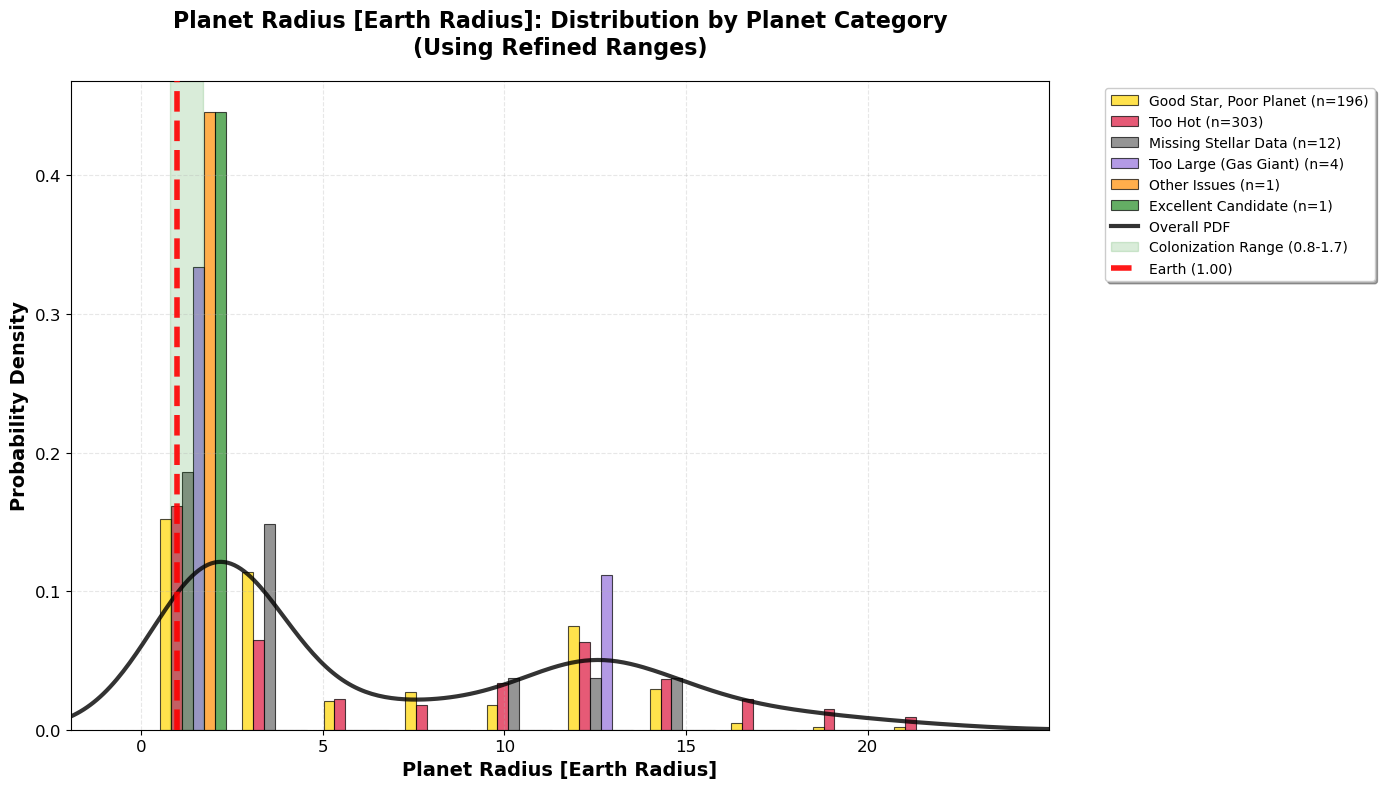

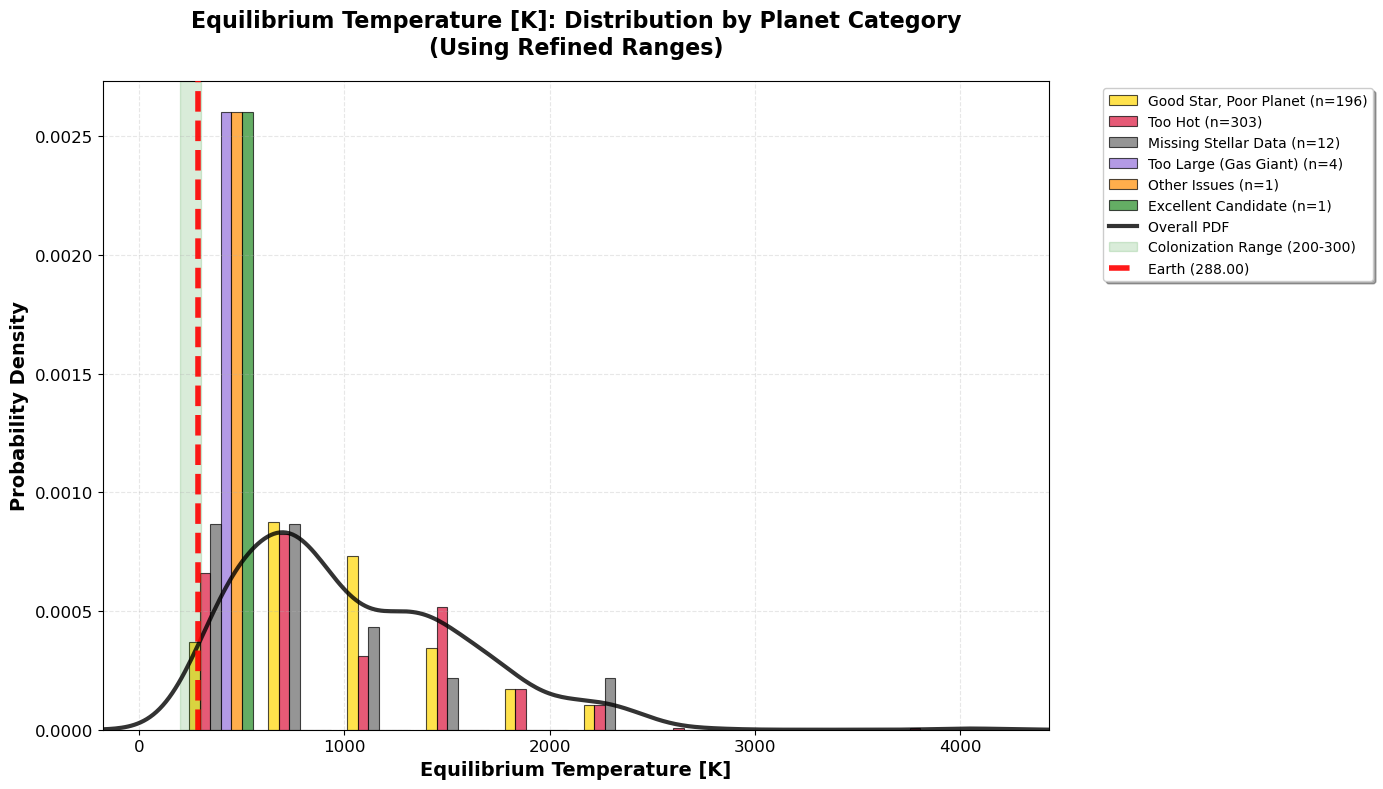

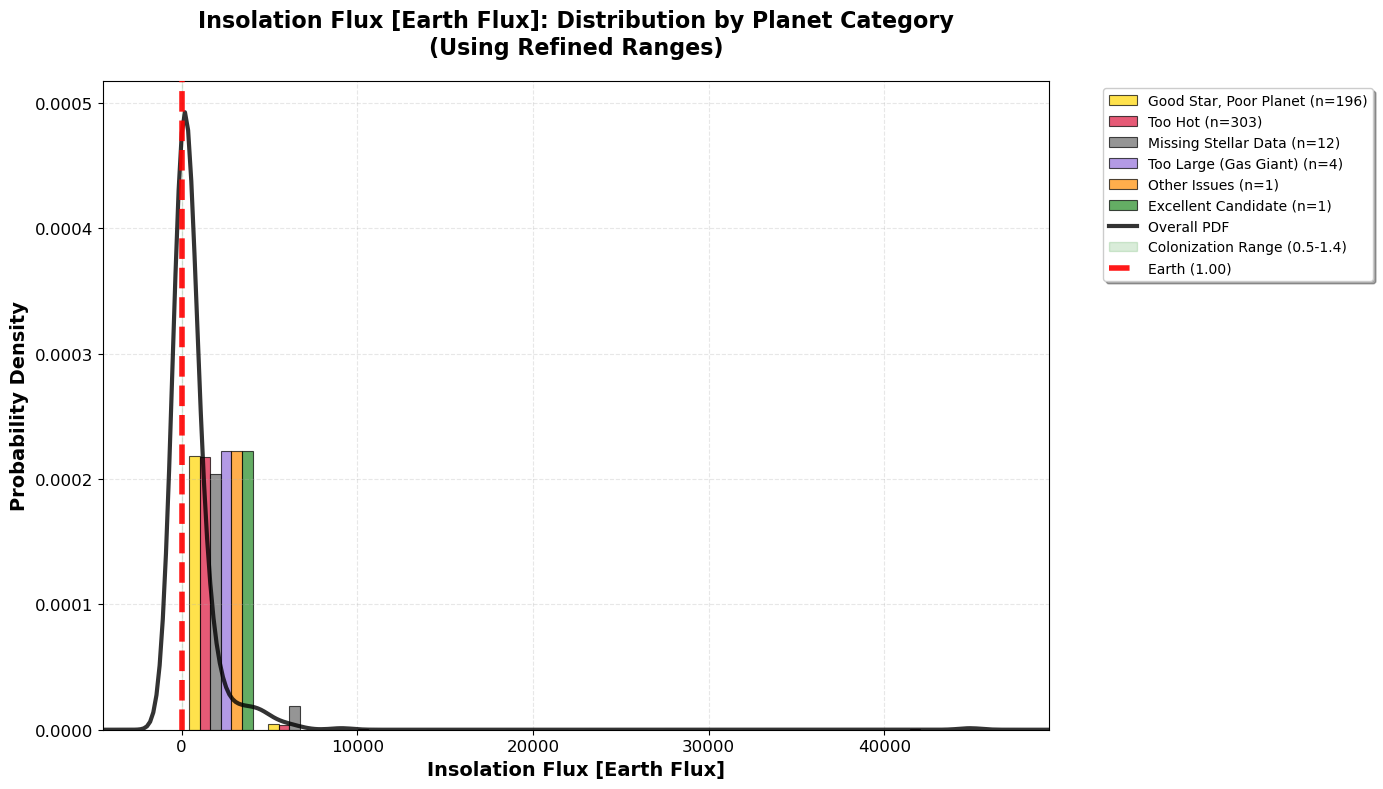

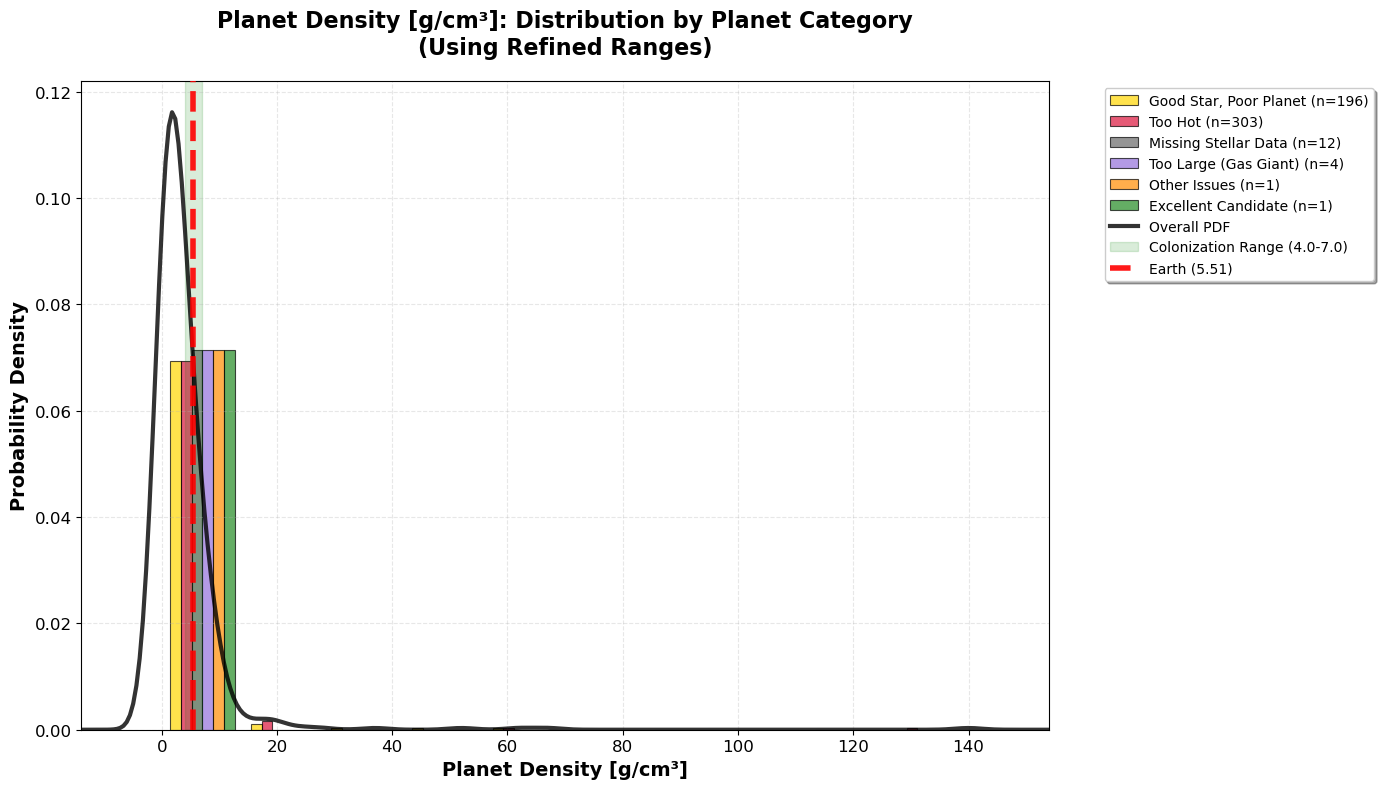

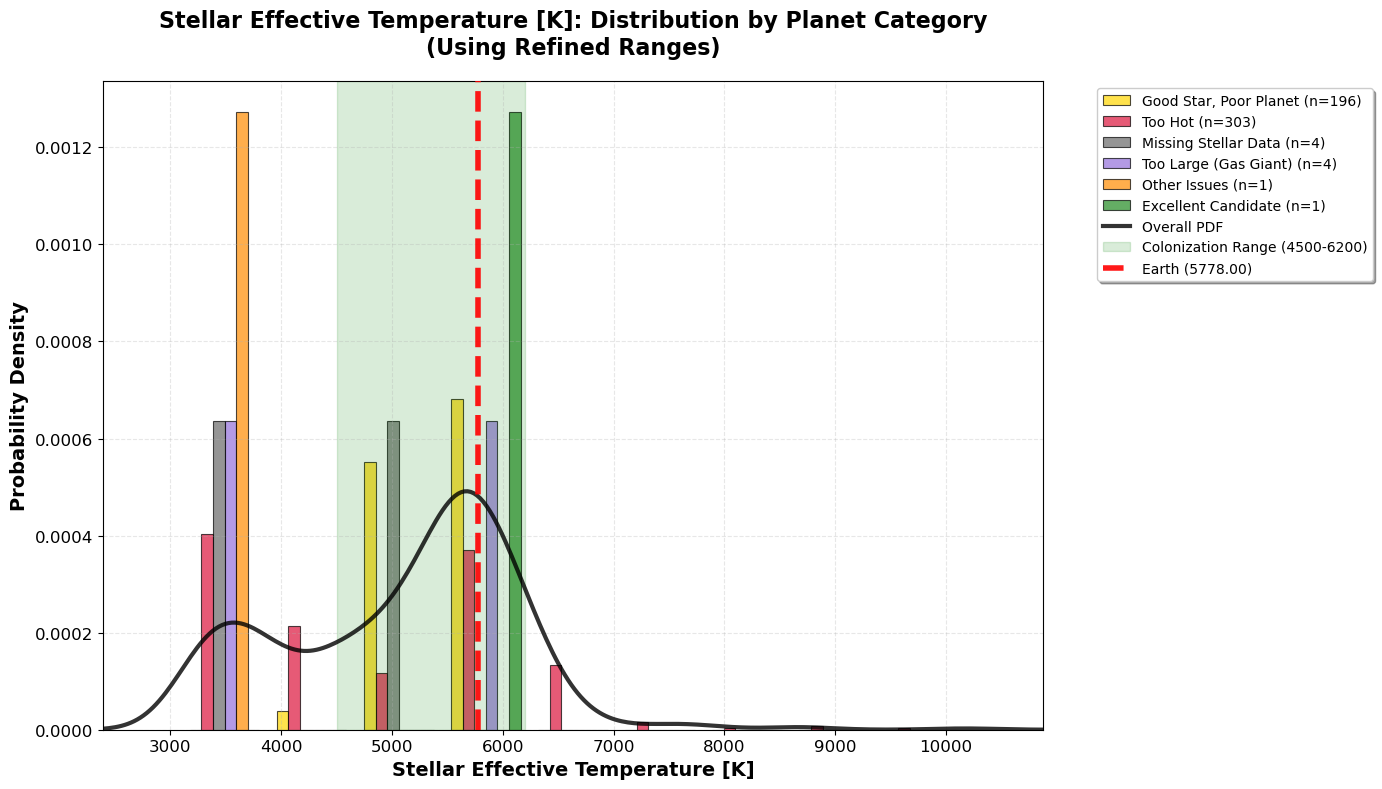

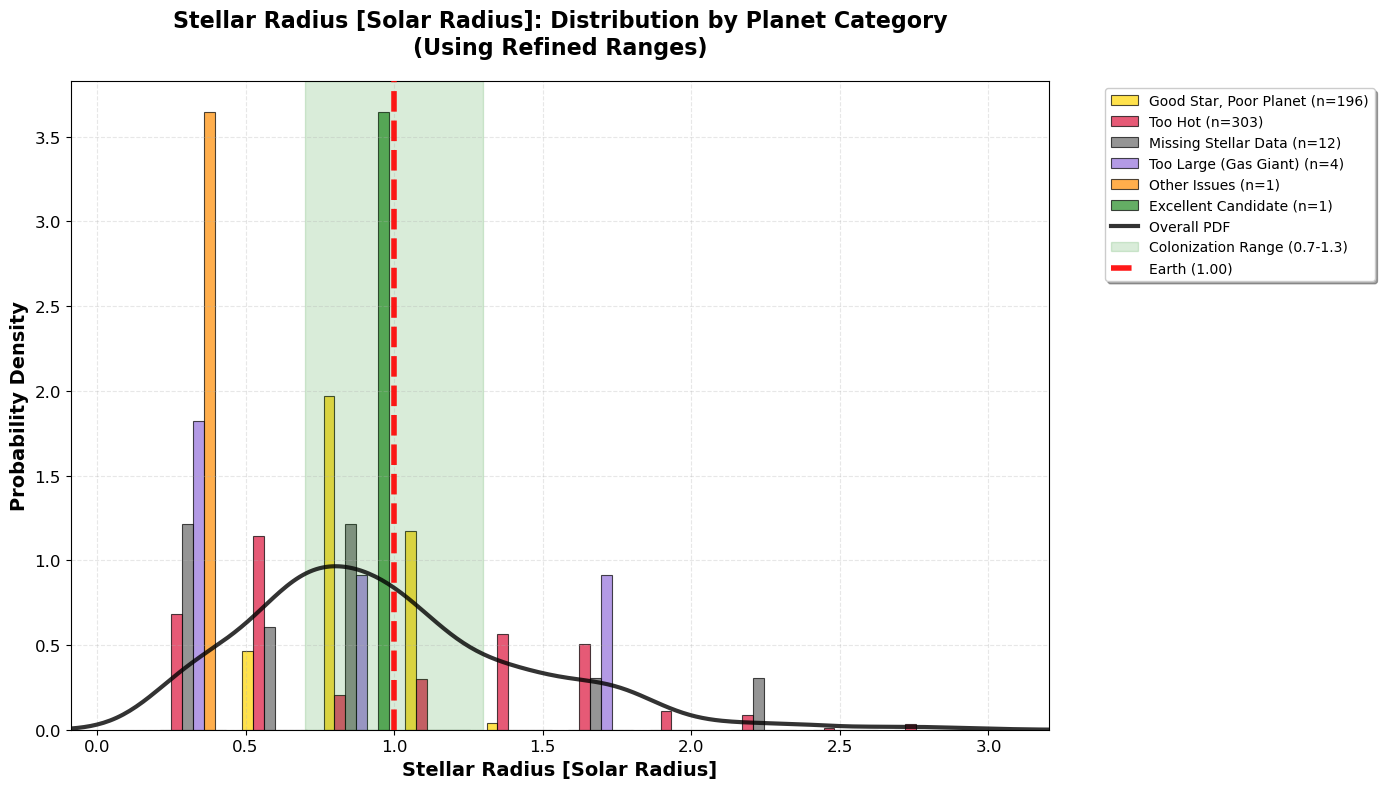

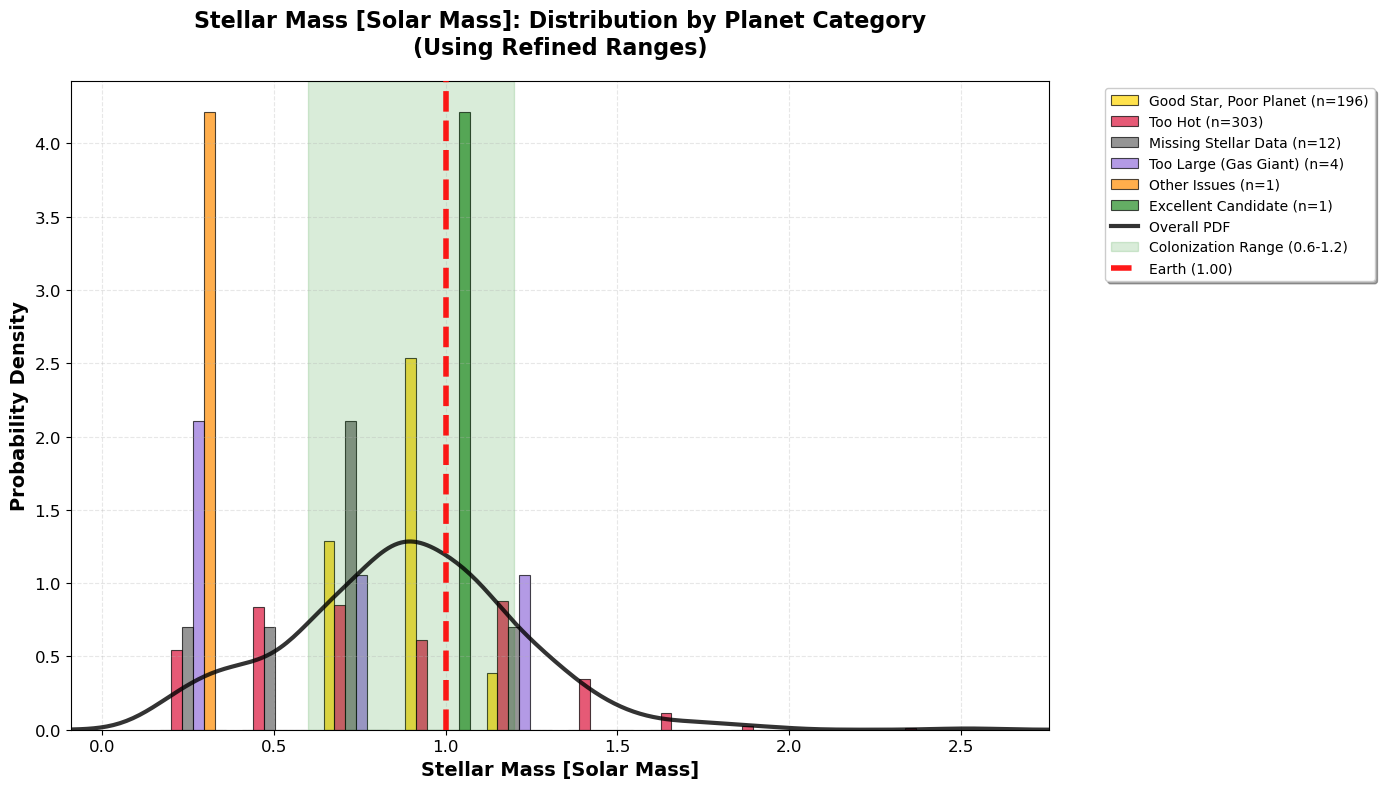

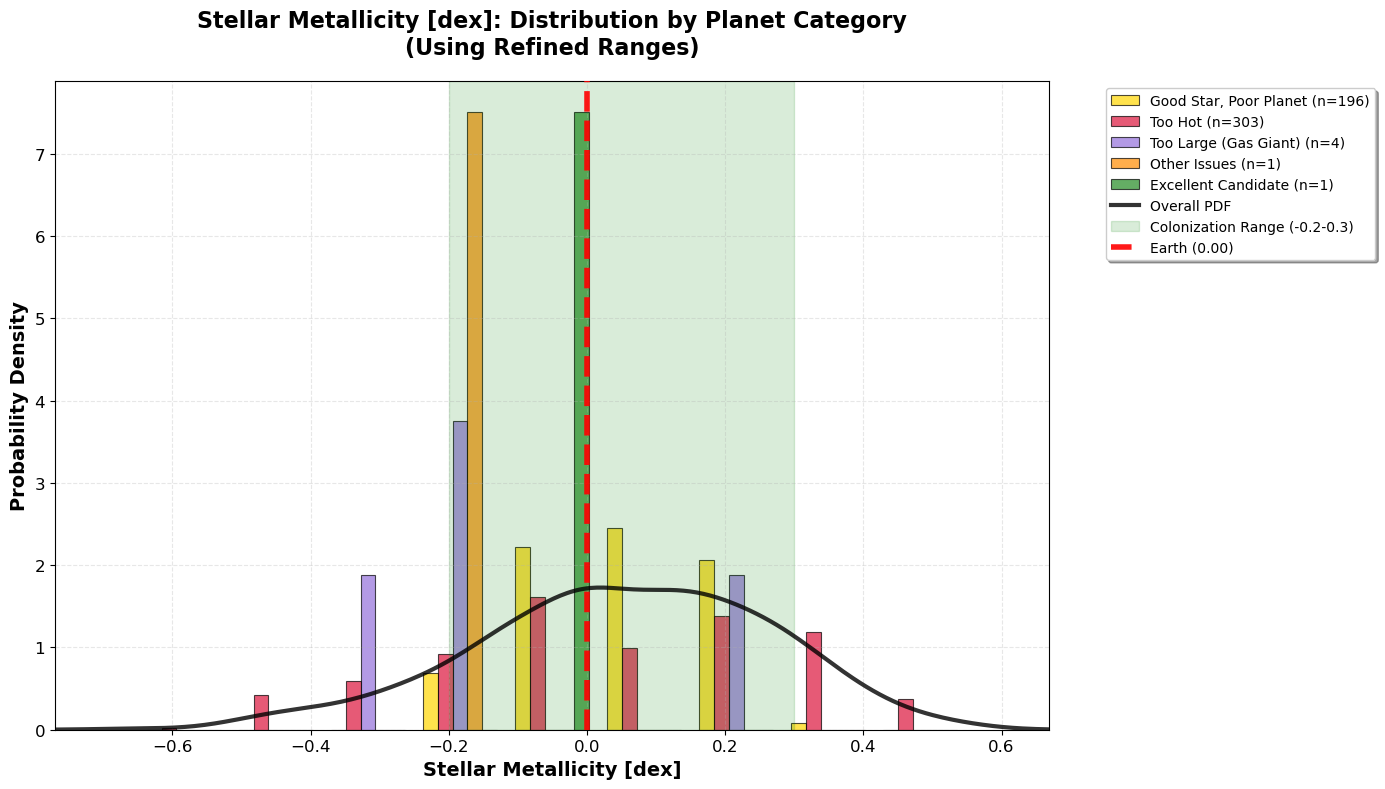


SIMPLIFIED ANALYSIS SUMMARY:

PL_RADE:
------------------------------
Colonization range: (0.8, 1.7)
Earth value: 1.000
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
  Too Hot: 303 (58.6%)
  Good Star, Poor Planet: 196 (37.9%)
  Missing Stellar Data: 12 (2.3%)

PL_EQT:
------------------------------
Colonization range: (200, 300)
Earth value: 288.000
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
  Too Hot: 303 (58.6%)
  Good Star, Poor Planet: 196 (37.9%)
  Missing Stellar Data: 12 (2.3%)

PL_INSOL:
------------------------------
Colonization range: (0.5, 1.4)
Earth value: 1.000
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
  Too Hot: 303 (58.6%)
  Good Star, Poor Planet: 196 (37.9%)
  Missing Stellar Data: 12 (2.3%)

PL_DENS:
------------------------------
Colonization range: (4.0, 7.0)
Earth value: 5.510
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import your existing data processing function
from data_processing import load_and_prepare_data

# Use refined ranges (you can change this to "original" or "earth_like" if preferred)
RANGE_PREFERENCE = "refined"

# Refined good value ranges for potentially colonizable planets
good_ranges_sets = {
    "original": {
        "pl_rade": (0.5, 3.0),
        "pl_eqt": (180, 310),
        "pl_insol": (0.25, 3.0),
        "pl_dens": (3.0, 8.0),
        "st_teff": (4000, 6500),
        "st_rad": (0.6, 1.4),
        "st_mass": (0.5, 1.5),
        "st_met": (-0.5, 0.5),
    },
    "refined": {
        "pl_rade": (0.8, 1.7),
        "pl_eqt": (200, 300),
        "pl_insol": (0.5, 1.4),
        "pl_dens": (4.0, 7.0),
        "st_teff": (4500, 6200),
        "st_rad": (0.7, 1.3),
        "st_mass": (0.6, 1.2),
        "st_met": (-0.2, 0.3),
    },
    "earth_like": {
        "pl_rade": (0.9, 1.3),
        "pl_eqt": (250, 290),
        "pl_insol": (0.8, 1.2),
        "pl_dens": (4.5, 6.5),
        "st_teff": (5000, 6000),
        "st_rad": (0.8, 1.2),
        "st_mass": (0.8, 1.1),
        "st_met": (-0.1, 0.2),
    }
}

def load_and_prepare_data_complete(file_path="data/Planetary-Systems-May-20-2025_clean.csv"):
    """
    Modified version of load_and_prepare_data with complete Earth stellar parameters
    """
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Data file '{file_path}' not found. Please make sure it exists.")
        return None

    if df.empty:
        print("Loaded DataFrame is empty. No data to plot.")
        return None

    coord_cols = ["ra", "dec", "sy_dist"]
    if not all(col in df.columns for col in coord_cols):
        print(f"Missing one or more coordinate columns {coord_cols} in the CSV.")
        return None
    
    df = df.dropna(subset=coord_cols).copy()

    if df.empty:
        print("DataFrame is empty after dropping NaNs in coordinate columns.")
        return None

    # Convert distance to light years
    PARSEC_TO_LY = 3.26156
    df["sy_dist_ly"] = df["sy_dist"] * PARSEC_TO_LY

    # Complete Earth data with stellar parameters
    earth_data_complete = {
        "pl_name": "Earth (Sol System)",
        "sy_dist": 0.0,
        "sy_dist_ly": 0.0,
        "ra": 0.0,
        "dec": 0.0,
        "pl_rade": 1.0,
        "pl_eqt": 288.0,
        "pl_insol": 1.0,
        "pl_dens": 5.51,
        "st_teff": 5778.0,     # Sun's effective temperature
        "st_rad": 1.0,         # Solar radius
        "st_mass": 1.0,        # Solar mass
        "st_met": 0.0,         # Solar metallicity
        "glon": np.nan,
        "glat": np.nan,
    }
    
    # Add Earth if not already present
    if not df["pl_name"].astype(str).str.contains("Earth", case=False).any():
        earth_df_row = pd.DataFrame([earth_data_complete])
        df = pd.concat([df, earth_df_row], ignore_index=True)

    return df

def categorize_planets_advanced(df, good_ranges):
    """
    Categorize planets based on multiple criteria for colonization potential
    """
    categories = []
    
    for _, row in df.iterrows():
        planetary_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens']
        stellar_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']
        
        # Check for missing data
        missing_planetary = any(pd.isna(row[feat]) for feat in planetary_features)
        missing_stellar = any(pd.isna(row[feat]) for feat in stellar_features)
        
        if missing_planetary and missing_stellar:
            categories.append('Insufficient Data')
            continue
        elif missing_planetary:
            categories.append('Missing Planetary Data')
            continue
        elif missing_stellar:
            categories.append('Missing Stellar Data')
            continue
        
        # Check planetary habitability
        planetary_good = True
        for feat in planetary_features:
            if feat in good_ranges:
                min_val, max_val = good_ranges[feat]
                if not (min_val <= row[feat] <= max_val):
                    planetary_good = False
                    break
        
        # Check stellar habitability
        stellar_good = True
        for feat in stellar_features:
            if feat in good_ranges:
                min_val, max_val = good_ranges[feat]
                if not (min_val <= row[feat] <= max_val):
                    stellar_good = False
                    break
        
        # Categorize based on results
        if planetary_good and stellar_good:
            categories.append('Excellent Candidate')
        elif planetary_good:
            categories.append('Good Planet, Poor Star')
        elif stellar_good:
            categories.append('Good Star, Poor Planet')
        else:
            # Further subcategorize problems
            temp = row['pl_eqt']
            if temp < good_ranges['pl_eqt'][0]:
                categories.append('Too Cold')
            elif temp > good_ranges['pl_eqt'][1]:
                categories.append('Too Hot')
            elif row['pl_rade'] > good_ranges['pl_rade'][1]:
                categories.append('Too Large (Gas Giant)')
            elif row['pl_rade'] < good_ranges['pl_rade'][0]:
                categories.append('Too Small')
            else:
                categories.append('Other Issues')
    
    return categories

def plot_simplified_categorical_histograms(df, features, feature_labels, good_ranges, save_plots=False):
    """
    Create simplified histograms with categories, good range, Earth line, and single overall PDF
    """
    # Add categories to dataframe
    df['planet_category'] = categorize_planets_advanced(df, good_ranges)
    
    # Define colors for categories
    category_colors = {
        'Excellent Candidate': '#228B22',        # Forest Green
        'Good Planet, Poor Star': '#32CD32',     # Lime Green
        'Good Star, Poor Planet': '#FFD700',     # Gold
        'Too Cold': '#4169E1',                   # Royal Blue
        'Too Hot': '#DC143C',                    # Crimson
        'Too Large (Gas Giant)': '#9370DB',      # Medium Purple
        'Too Small': '#FF69B4',                  # Hot Pink
        'Other Issues': '#FF8C00',               # Dark Orange
        'Missing Planetary Data': '#A9A9A9',     # Dark Gray
        'Missing Stellar Data': '#696969',       # Dim Gray
        'Insufficient Data': '#D3D3D3'           # Light Gray
    }
    
    # Extract Earth's values
    earth_row = df[df["pl_name"].str.lower().str.contains("earth", na=False)]
    if len(earth_row) > 0:
        earth_row = earth_row.iloc[0]
    else:
        earth_row = None
    
    # Print category statistics
    print("PLANET CATEGORIZATION RESULTS:")
    print("=" * 40)
    category_counts = df['planet_category'].value_counts()
    for category, count in category_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{category}: {count} planets ({percentage:.1f}%)")
    
    results = {}
    
    for col in features:
        plt.figure(figsize=(14, 8))  # Made wider for better visibility
        
        # Clean data for this feature
        df_clean = df[df[col].notna()].copy()
        
        if len(df_clean) == 0:
            print(f"No data available for {col}")
            continue
        
        # Get all data for bin calculation
        all_data = df_clean[col].dropna()
        
        # Plot stacked histogram by category
        categories_present = df_clean['planet_category'].unique()
        categories_data = []
        labels = []
        colors = []
        
        for category in categories_present:
            if category in category_colors:
                category_data = df_clean[df_clean['planet_category'] == category][col]
                if len(category_data) > 0:
                    categories_data.append(category_data)
                    labels.append(f'{category} (n={len(category_data)})')
                    colors.append(category_colors[category])
        
        # Determine optimal number of bins based on data range and sample size
        if len(all_data) > 0:
            data_range = all_data.max() - all_data.min()
            if data_range > 0:
                # Use Sturges' rule but cap between 8-25 bins for visibility
                sturges_bins = int(np.log2(len(all_data)) + 1)
                n_bins = min(25, max(8, sturges_bins))
            else:
                n_bins = 10
        else:
            n_bins = 10
            
        # Create histogram with better bin sizing
        plt.hist(categories_data, bins=n_bins, alpha=0.7, color=colors, label=labels, 
                density=True, edgecolor='black', linewidth=0.8, stacked=False)
        
        # Add overall PDF for entire dataset
        all_data = df_clean[col].dropna()
        if len(all_data) > 3:
            kde = stats.gaussian_kde(all_data)
            # Use the same x range as the histogram for consistency
            if len(all_data) > 0:
                data_min, data_max = all_data.min(), all_data.max()
                data_range = data_max - data_min
                padding = data_range * 0.1 if data_range > 0 else 1
                x_range = np.linspace(data_min - padding, data_max + padding, 300)
            else:
                x_range = np.linspace(all_data.min(), all_data.max(), 300)
            
            y_range = kde(x_range)
            plt.plot(x_range, y_range, color='black', linewidth=3, 
                    linestyle='-', alpha=0.8, label='Overall PDF', zorder=4)
        
        # Add good range shading
        if col in good_ranges:
            good_min, good_max = good_ranges[col]
            plt.axvspan(good_min, good_max, color='green', alpha=0.15, 
                       label=f"Colonization Range ({good_min}-{good_max})", zorder=1)
        
        # Add Earth line with enhanced visibility
        if earth_row is not None and pd.notna(earth_row[col]):
            earth_val = earth_row[col]
            plt.axvline(earth_val, color='red', linestyle='--', linewidth=4, 
                       label=f"Earth ({earth_val:.2f})", alpha=0.9, zorder=6)
        
        # Set better axis limits for visibility
        if len(all_data) > 0:
            data_min, data_max = all_data.min(), all_data.max()
            data_range = data_max - data_min
            
            # Add padding to show data clearly
            padding = data_range * 0.1 if data_range > 0 else 1
            x_min = data_min - padding
            x_max = data_max + padding
            
            # Special handling for Earth value if it's outside main data range
            if earth_row is not None and pd.notna(earth_row[col]):
                earth_val = earth_row[col]
                x_min = min(x_min, earth_val - padding)
                x_max = max(x_max, earth_val + padding)
            
            plt.xlim(x_min, x_max)
        
        # Formatting
        full_label = feature_labels[col]
        plt.title(f"{full_label}: Distribution by Planet Category\n(Using {RANGE_PREFERENCE.title()} Ranges)", 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel(full_label, fontsize=14, fontweight='bold')
        plt.ylabel("Probability Density", fontsize=14, fontweight='bold')
        
        # Improve tick labels
        plt.tick_params(axis='both', which='major', labelsize=12)
        
        # Adjust legend - put it outside the plot
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, 
                  frameon=True, fancybox=True, shadow=True)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f'{col}_simplified_categorical.png', dpi=300, bbox_inches='tight')
        
        plt.show()
        
        # Store results for analysis
        results[col] = {
            'good_range': good_ranges.get(col, None),
            'earth_value': earth_row[col] if earth_row is not None and pd.notna(earth_row[col]) else None,
            'total_count': len(df_clean),
            'categories': dict(df_clean['planet_category'].value_counts())
        }
    
    return results, df

def analyze_simplified_results(results):
    """
    Analyze the simplified results to extract insights
    """
    print("\nSIMPLIFIED ANALYSIS SUMMARY:")
    print("=" * 50)
    
    for feature, data in results.items():
        print(f"\n{feature.upper()}:")
        print("-" * 30)
        
        good_range = data['good_range']
        earth_value = data['earth_value']
        
        if good_range:
            print(f"Colonization range: {good_range}")
        if earth_value is not None:
            print(f"Earth value: {earth_value:.3f}")
            if good_range:
                in_range = good_range[0] <= earth_value <= good_range[1]
                print(f"Earth in colonization range: {'✓ YES' if in_range else '✗ NO'}")
        
        print(f"Total planets with data: {data['total_count']}")
        
        # Show top categories
        print("Top categories:")
        for category, count in sorted(data['categories'].items(), key=lambda x: x[1], reverse=True)[:3]:
            percentage = (count / data['total_count']) * 100
            print(f"  {category}: {count} ({percentage:.1f}%)")

# Main execution
if __name__ == "__main__":
    # Load data with complete Earth parameters
    df = load_and_prepare_data_complete("data/Planetary-Systems-May-20-2025_clean.csv")
    
    if df is None:
        print("Failed to load data. Please check the file path.")
        exit()
    
    # Define features and labels
    features = ["pl_rade", "pl_eqt", "pl_insol", "pl_dens", "st_teff", "st_rad", "st_mass", "st_met"]
    feature_labels = {
        "pl_rade": "Planet Radius [Earth Radius]",
        "pl_eqt": "Equilibrium Temperature [K]",
        "pl_insol": "Insolation Flux [Earth Flux]",
        "pl_dens": "Planet Density [g/cm³]",
        "st_teff": "Stellar Effective Temperature [K]",
        "st_rad": "Stellar Radius [Solar Radius]",
        "st_mass": "Stellar Mass [Solar Mass]",
        "st_met": "Stellar Metallicity [dex]",
    }
    
    # Get the selected good ranges
    good_ranges = good_ranges_sets[RANGE_PREFERENCE]
    
    # Create the simplified categorical plots
    results, df_with_categories = plot_simplified_categorical_histograms(
        df, features, feature_labels, good_ranges, save_plots=False)
    
    # Analyze results
    analyze_simplified_results(results)
    
    # Show Earth's classification
    print(f"\nEARTH'S CLASSIFICATION:")
    print("=" * 30)
    earth_category = df_with_categories[df_with_categories["pl_name"].str.contains("Earth", case=False, na=False)]['planet_category'].iloc[0]
    print(f"Earth is classified as: {earth_category}")
    
    # Optional: Save categorized data
    # df_with_categories.to_csv('exoplanets_categorized_complete.csv', index=False)

PLANET CATEGORIZATION RESULTS:
Good Star, Poor Planet: 388 planets (75.0%)
Too Hot: 97 planets (18.8%)
Missing Stellar Data: 12 planets (2.3%)
Other Issues: 8 planets (1.5%)
Good Planet, Poor Star: 6 planets (1.2%)
Too Large (Gas Giant): 3 planets (0.6%)
Excellent Candidate: 3 planets (0.6%)


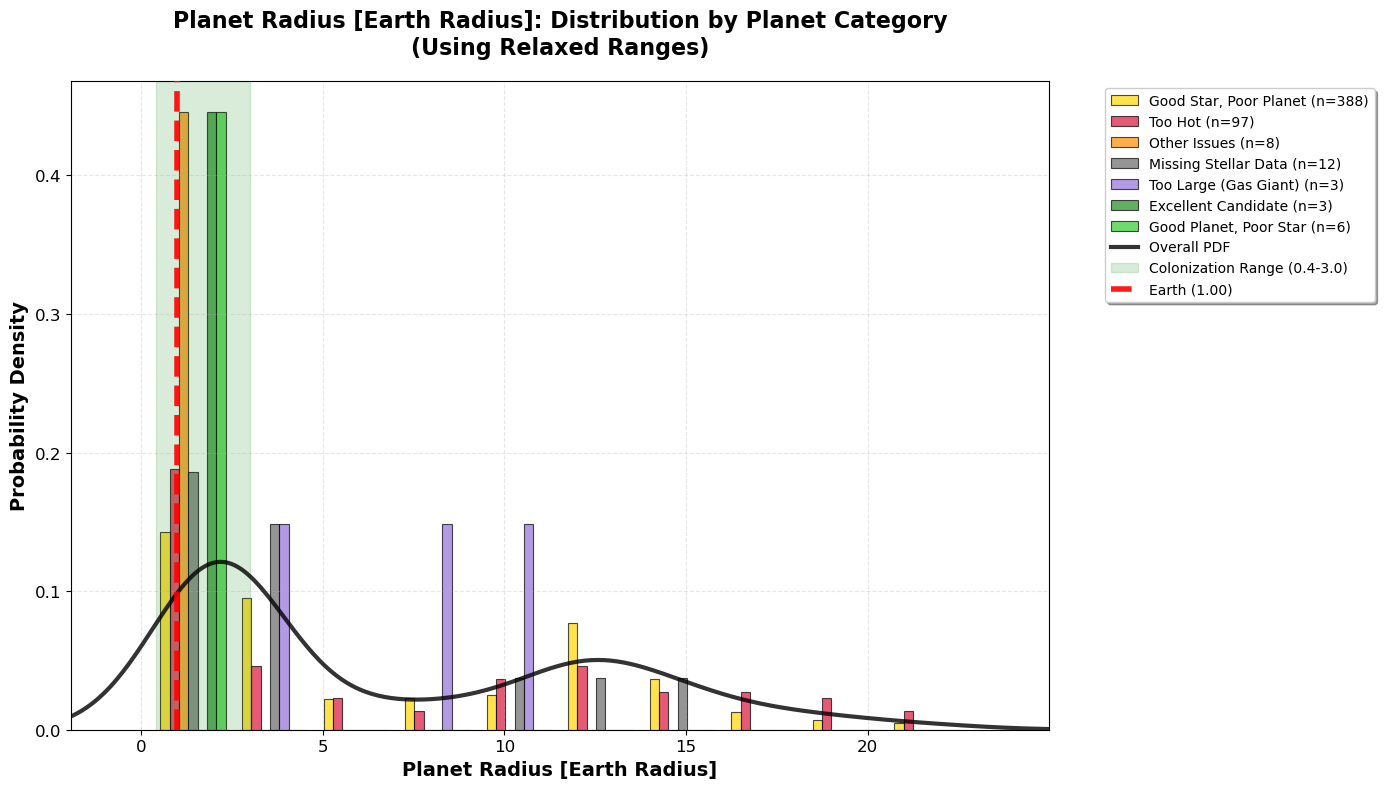

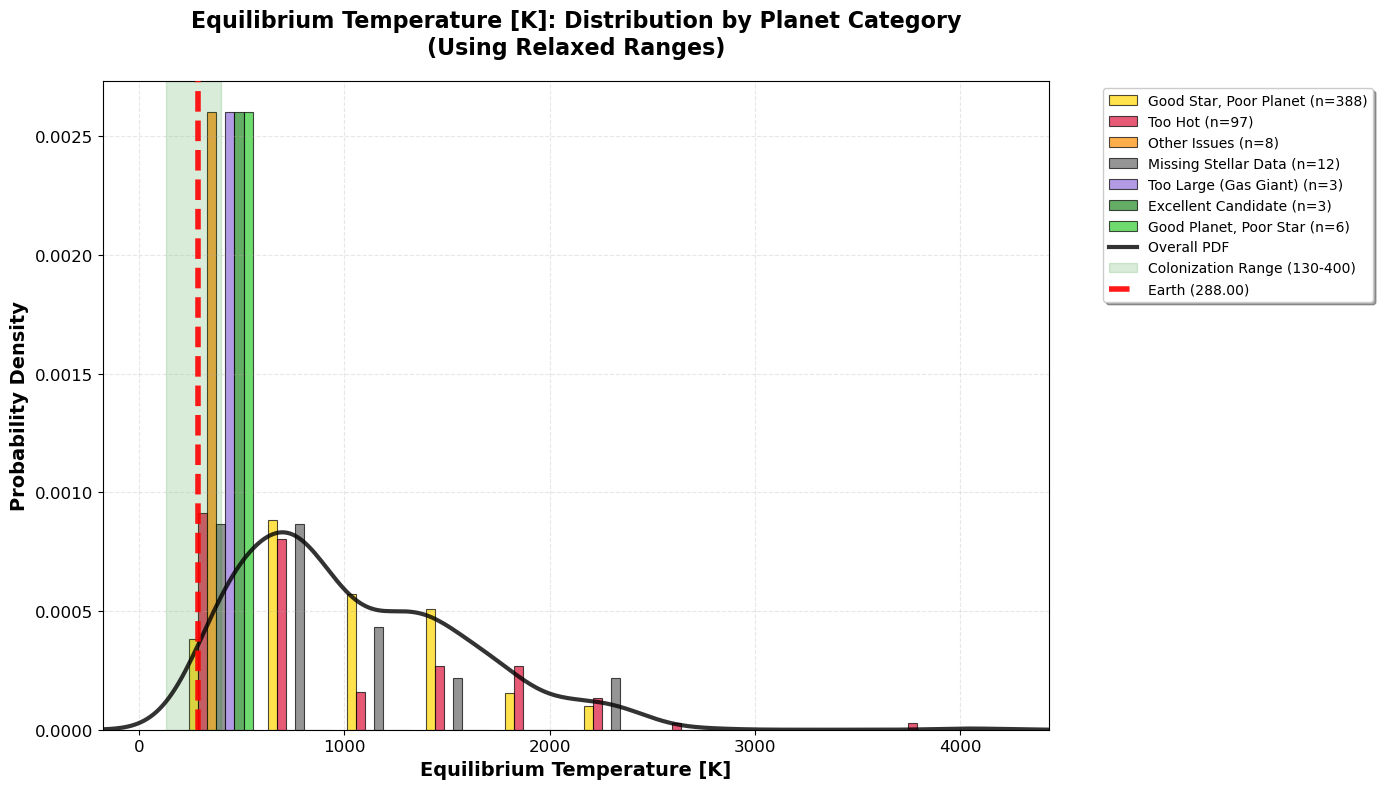

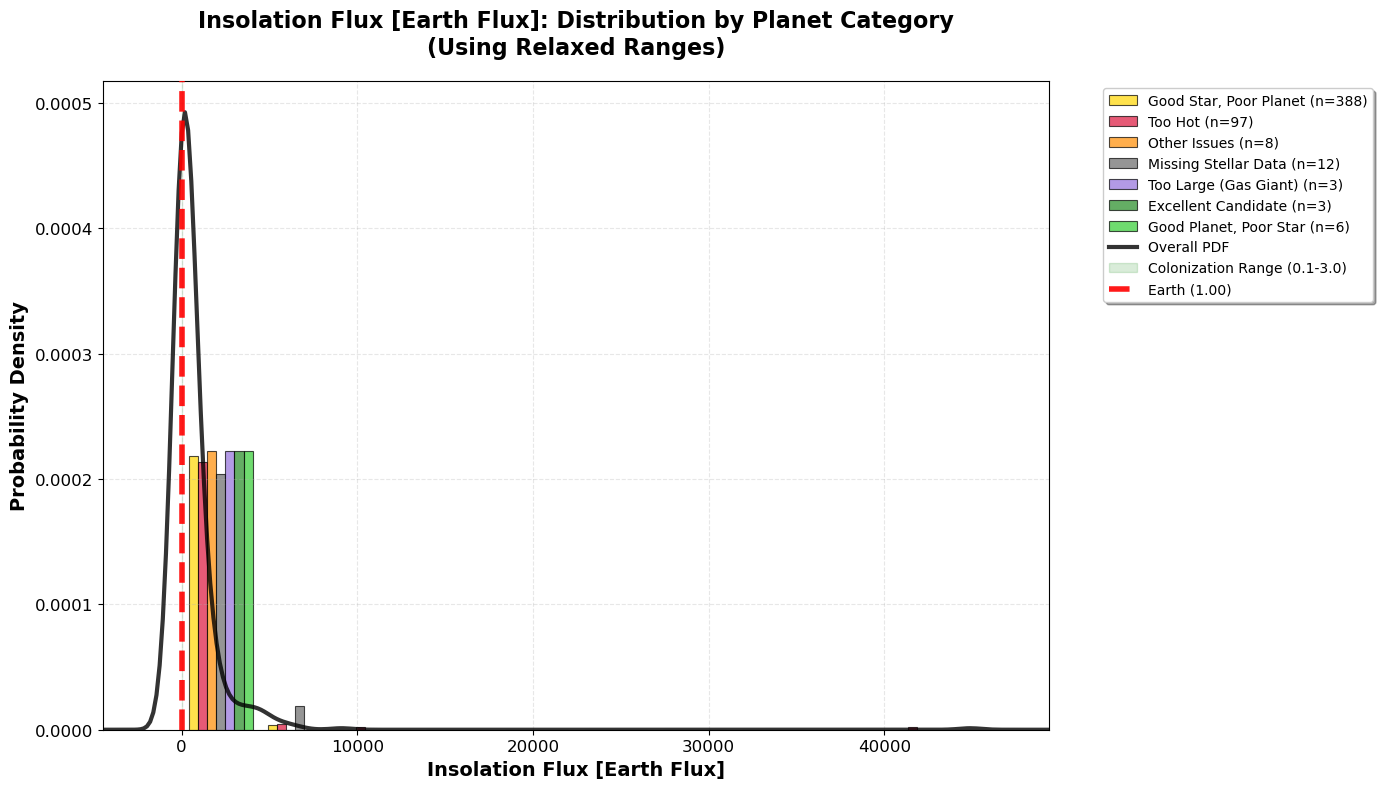

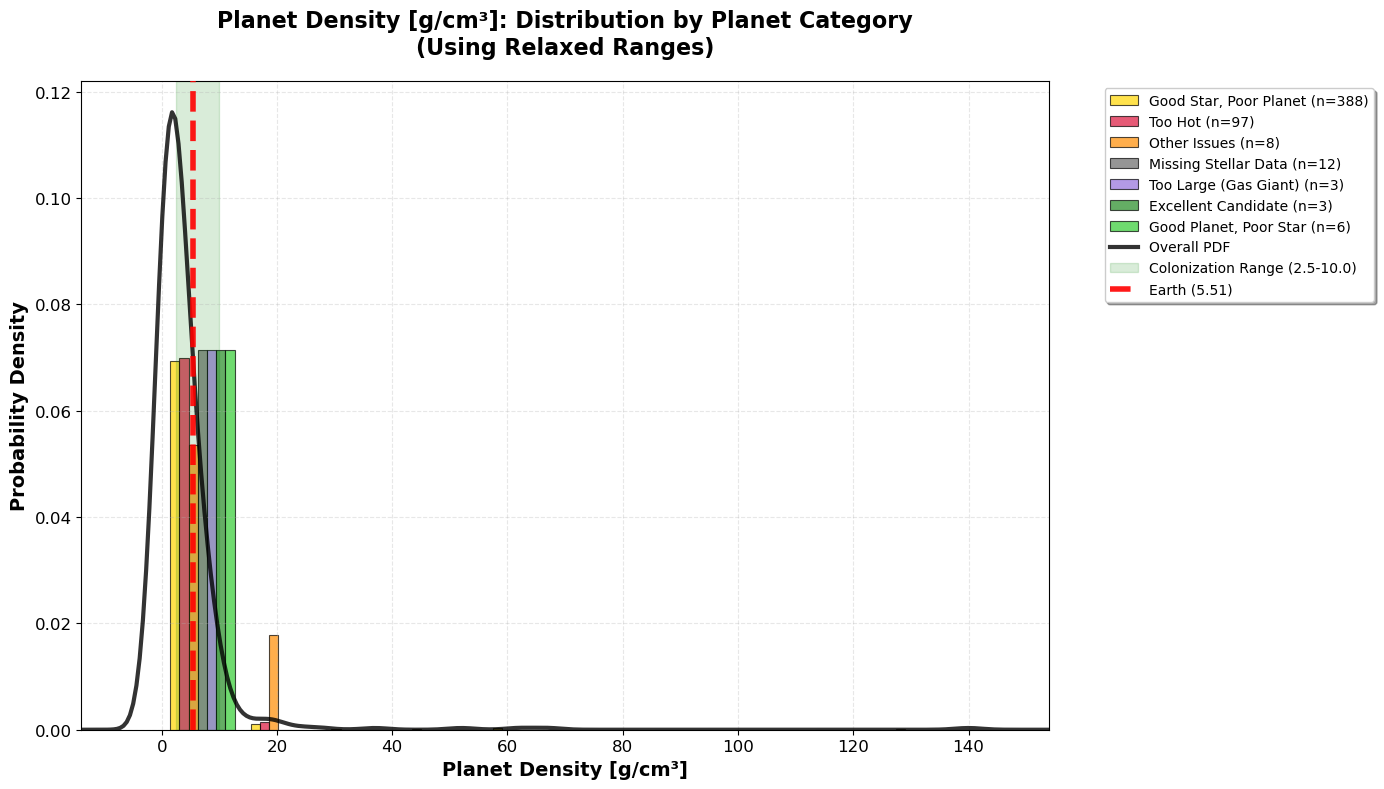

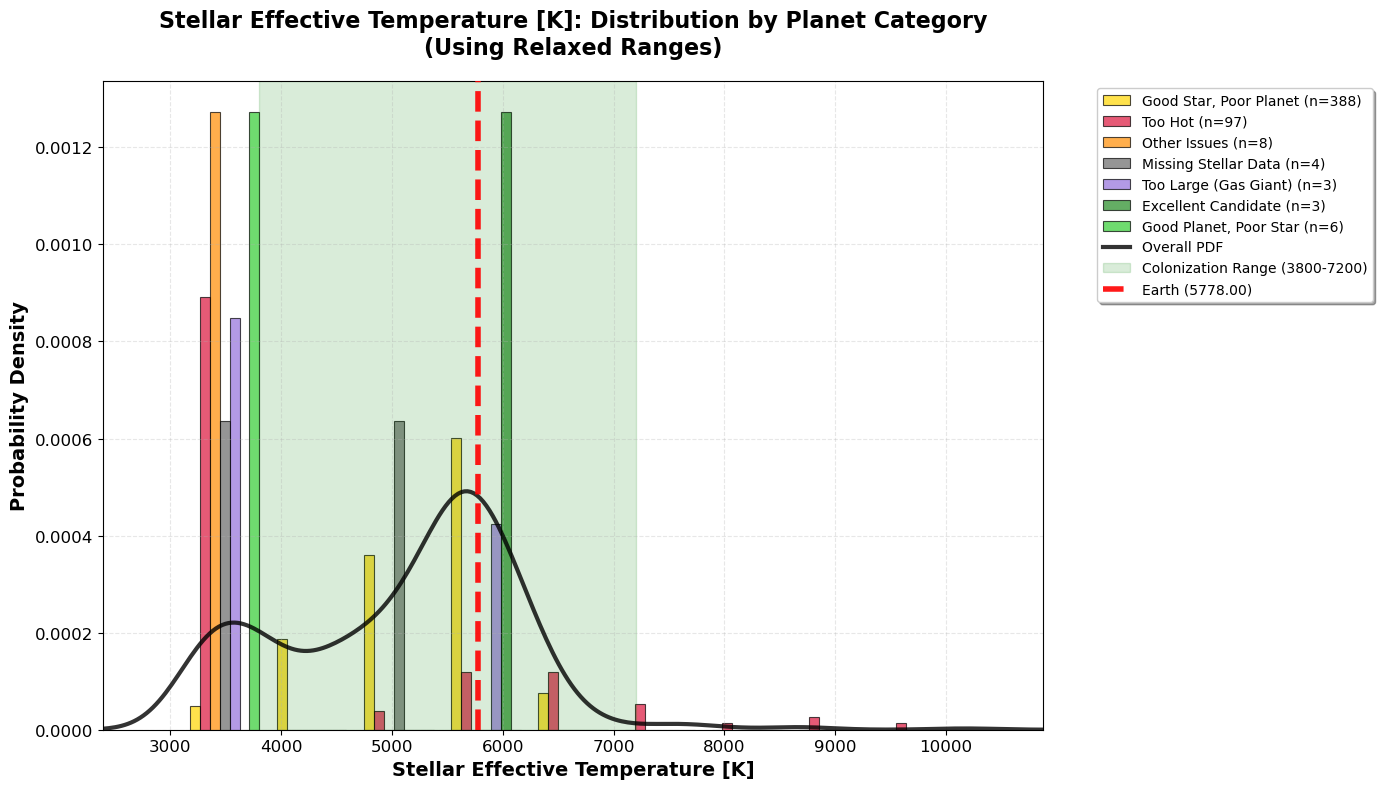

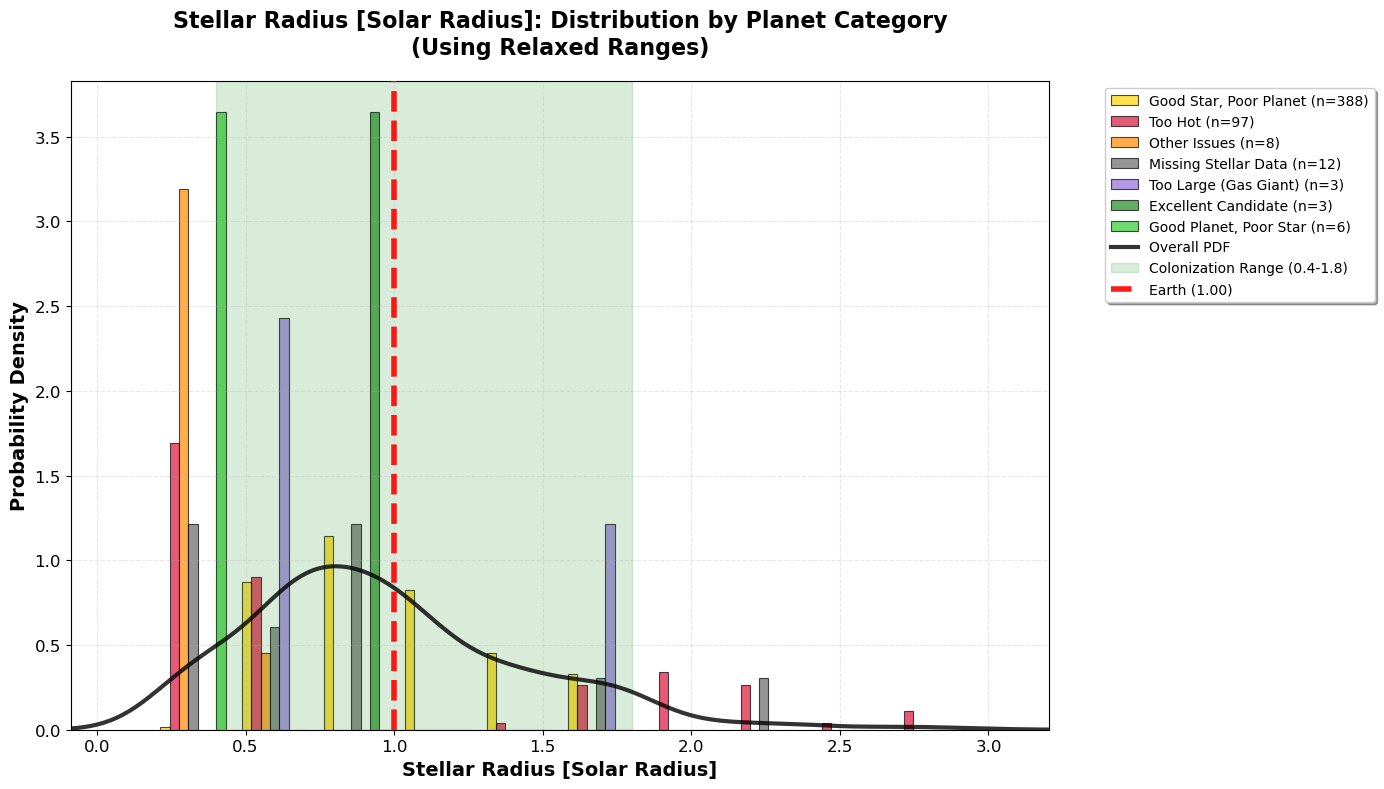

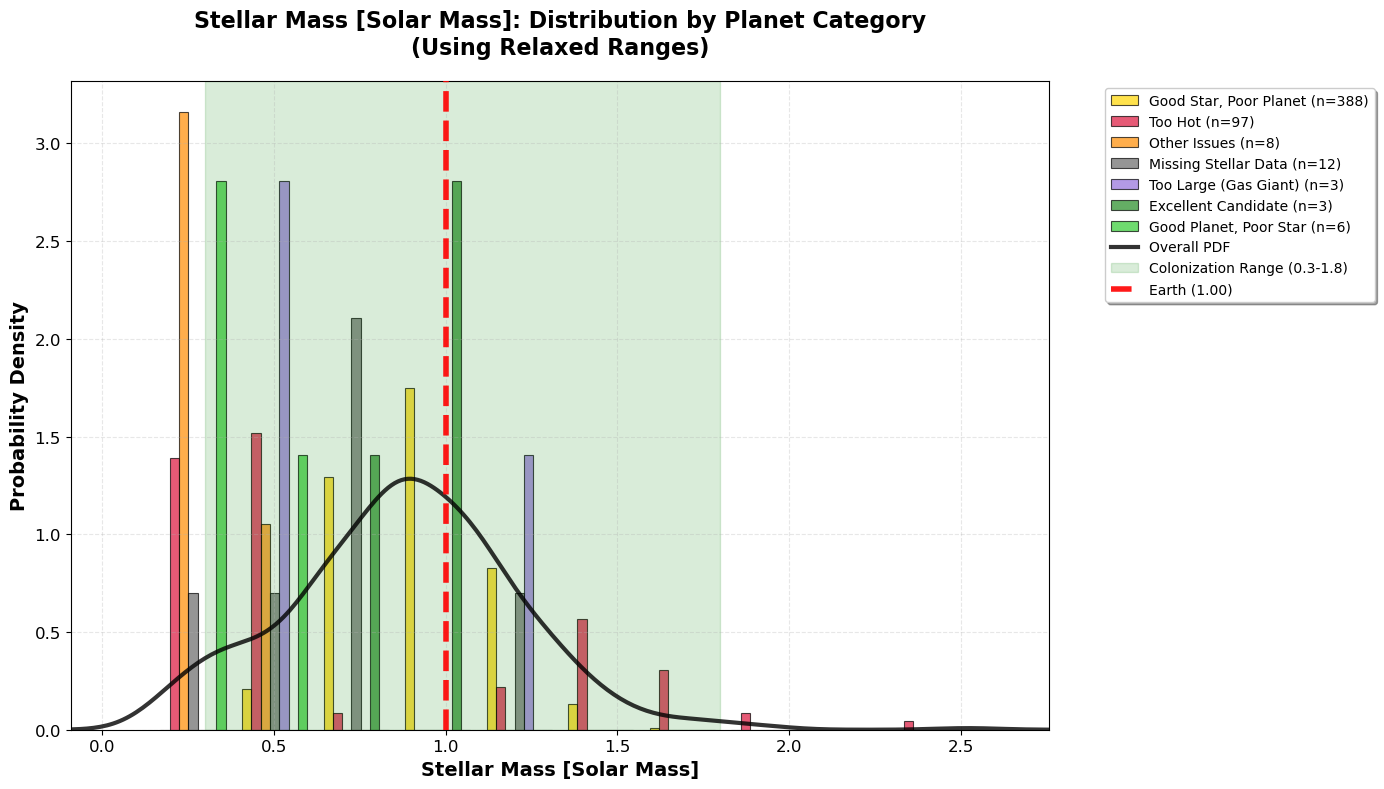

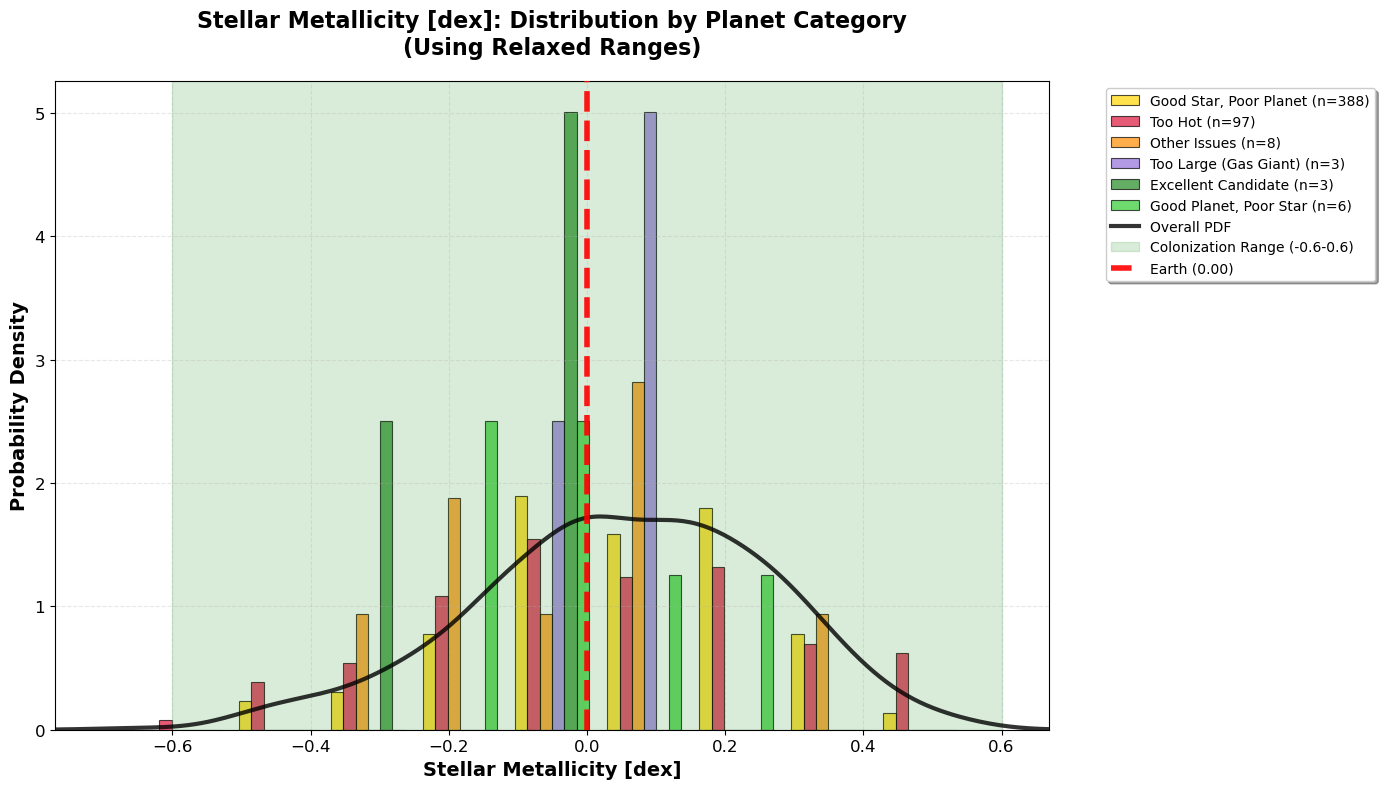


SIMPLIFIED ANALYSIS SUMMARY:

PL_RADE:
------------------------------
Colonization range: (0.4, 3.0)
Earth value: 1.000
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
  Good Star, Poor Planet: 388 (75.0%)
  Too Hot: 97 (18.8%)
  Missing Stellar Data: 12 (2.3%)

PL_EQT:
------------------------------
Colonization range: (130, 400)
Earth value: 288.000
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
  Good Star, Poor Planet: 388 (75.0%)
  Too Hot: 97 (18.8%)
  Missing Stellar Data: 12 (2.3%)

PL_INSOL:
------------------------------
Colonization range: (0.1, 3.0)
Earth value: 1.000
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
  Good Star, Poor Planet: 388 (75.0%)
  Too Hot: 97 (18.8%)
  Missing Stellar Data: 12 (2.3%)

PL_DENS:
------------------------------
Colonization range: (2.5, 10.0)
Earth value: 5.510
Earth in colonization range: ✓ YES
Total planets with data: 517
Top categories:
 

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import your existing data processing function
from data_processing import load_and_prepare_data

# Use moderate ranges for better statistical power (you can change this to "refined", "relaxed", "original", or "earth_like")
RANGE_PREFERENCE = "relaxed"

# Updated threshold sets with better options for statistical analysis
good_ranges_sets = {
    "original": {
        "pl_rade": (0.5, 3.0),
        "pl_eqt": (180, 310),
        "pl_insol": (0.25, 3.0),
        "pl_dens": (3.0, 8.0),
        "st_teff": (4000, 6500),
        "st_rad": (0.6, 1.4),
        "st_mass": (0.5, 1.5),
        "st_met": (-0.5, 0.5),
    },
    "refined": {  # Your previous strict criteria - only Earth passes
        "pl_rade": (0.8, 1.7),
        "pl_eqt": (200, 300),
        "pl_insol": (0.5, 1.4),
        "pl_dens": (4.0, 7.0),
        "st_teff": (4500, 6200),
        "st_rad": (0.7, 1.3),
        "st_mass": (0.6, 1.2),
        "st_met": (-0.2, 0.3),
    },
    "relaxed": {
            "pl_rade": (0.4, 3.0),
            "pl_eqt": (130, 400),
            "pl_insol": (0.1, 3.0),
            "pl_dens": (2.5, 10.0),
            "st_teff": (3800, 7200),
            "st_rad": (0.4, 1.8),
            "st_mass": (0.3, 1.8),
            "st_met": (-0.6, 0.6),
    },
    "earth_like": {  # Most restrictive - very few candidates
        "pl_rade": (0.9, 1.3),
        "pl_eqt": (250, 290),
        "pl_insol": (0.8, 1.2),
        "pl_dens": (4.5, 6.5),
        "st_teff": (5000, 6000),
        "st_rad": (0.8, 1.2),
        "st_mass": (0.8, 1.1),
        "st_met": (-0.1, 0.2),
    }
}

def load_and_prepare_data_complete(file_path="data/Planetary-Systems-May-20-2025_clean.csv"):
    """
    Modified version of load_and_prepare_data with complete Earth stellar parameters
    """
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Data file '{file_path}' not found. Please make sure it exists.")
        return None

    if df.empty:
        print("Loaded DataFrame is empty. No data to plot.")
        return None

    coord_cols = ["ra", "dec", "sy_dist"]
    if not all(col in df.columns for col in coord_cols):
        print(f"Missing one or more coordinate columns {coord_cols} in the CSV.")
        return None
    
    df = df.dropna(subset=coord_cols).copy()

    if df.empty:
        print("DataFrame is empty after dropping NaNs in coordinate columns.")
        return None

    # Convert distance to light years
    PARSEC_TO_LY = 3.26156
    df["sy_dist_ly"] = df["sy_dist"] * PARSEC_TO_LY

    # Complete Earth data with stellar parameters
    earth_data_complete = {
        "pl_name": "Earth (Sol System)",
        "sy_dist": 0.0,
        "sy_dist_ly": 0.0,
        "ra": 0.0,
        "dec": 0.0,
        "pl_rade": 1.0,
        "pl_eqt": 288.0,
        "pl_insol": 1.0,
        "pl_dens": 5.51,
        "st_teff": 5778.0,     # Sun's effective temperature
        "st_rad": 1.0,         # Solar radius
        "st_mass": 1.0,        # Solar mass
        "st_met": 0.0,         # Solar metallicity
        "glon": np.nan,
        "glat": np.nan,
    }
    
    # Add Earth if not already present
    if not df["pl_name"].astype(str).str.contains("Earth", case=False).any():
        earth_df_row = pd.DataFrame([earth_data_complete])
        df = pd.concat([df, earth_df_row], ignore_index=True)

    return df

def categorize_planets_advanced(df, good_ranges):
    """
    Categorize planets based on multiple criteria for colonization potential
    """
    categories = []
    
    for _, row in df.iterrows():
        planetary_features = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens']
        stellar_features = ['st_teff', 'st_rad', 'st_mass', 'st_met']
        
        # Check for missing data
        missing_planetary = any(pd.isna(row[feat]) for feat in planetary_features)
        missing_stellar = any(pd.isna(row[feat]) for feat in stellar_features)
        
        if missing_planetary and missing_stellar:
            categories.append('Insufficient Data')
            continue
        elif missing_planetary:
            categories.append('Missing Planetary Data')
            continue
        elif missing_stellar:
            categories.append('Missing Stellar Data')
            continue
        
        # Check planetary habitability
        planetary_good = True
        for feat in planetary_features:
            if feat in good_ranges:
                min_val, max_val = good_ranges[feat]
                if not (min_val <= row[feat] <= max_val):
                    planetary_good = False
                    break
        
        # Check stellar habitability
        stellar_good = True
        for feat in stellar_features:
            if feat in good_ranges:
                min_val, max_val = good_ranges[feat]
                if not (min_val <= row[feat] <= max_val):
                    stellar_good = False
                    break
        
        # Categorize based on results
        if planetary_good and stellar_good:
            categories.append('Excellent Candidate')
        elif planetary_good:
            categories.append('Good Planet, Poor Star')
        elif stellar_good:
            categories.append('Good Star, Poor Planet')
        else:
            # Further subcategorize problems
            temp = row['pl_eqt']
            if temp < good_ranges['pl_eqt'][0]:
                categories.append('Too Cold')
            elif temp > good_ranges['pl_eqt'][1]:
                categories.append('Too Hot')
            elif row['pl_rade'] > good_ranges['pl_rade'][1]:
                categories.append('Too Large (Gas Giant)')
            elif row['pl_rade'] < good_ranges['pl_rade'][0]:
                categories.append('Too Small')
            else:
                categories.append('Other Issues')
    
    return categories

def plot_simplified_categorical_histograms(df, features, feature_labels, good_ranges, save_plots=False):
    """
    Create simplified histograms with categories, good range, Earth line, and single overall PDF
    """
    # Add categories to dataframe
    df['planet_category'] = categorize_planets_advanced(df, good_ranges)
    
    # Define colors for categories
    category_colors = {
        'Excellent Candidate': '#228B22',        # Forest Green
        'Good Planet, Poor Star': '#32CD32',     # Lime Green
        'Good Star, Poor Planet': '#FFD700',     # Gold
        'Too Cold': '#4169E1',                   # Royal Blue
        'Too Hot': '#DC143C',                    # Crimson
        'Too Large (Gas Giant)': '#9370DB',      # Medium Purple
        'Too Small': '#FF69B4',                  # Hot Pink
        'Other Issues': '#FF8C00',               # Dark Orange
        'Missing Planetary Data': '#A9A9A9',     # Dark Gray
        'Missing Stellar Data': '#696969',       # Dim Gray
        'Insufficient Data': '#D3D3D3'           # Light Gray
    }
    
    # Extract Earth's values
    earth_row = df[df["pl_name"].str.lower().str.contains("earth", na=False)]
    if len(earth_row) > 0:
        earth_row = earth_row.iloc[0]
    else:
        earth_row = None
    
    # Print category statistics
    print("PLANET CATEGORIZATION RESULTS:")
    print("=" * 40)
    category_counts = df['planet_category'].value_counts()
    for category, count in category_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{category}: {count} planets ({percentage:.1f}%)")
    
    results = {}
    
    for col in features:
        plt.figure(figsize=(14, 8))  # Made wider for better visibility
        
        # Clean data for this feature
        df_clean = df[df[col].notna()].copy()
        
        if len(df_clean) == 0:
            print(f"No data available for {col}")
            continue
        
        # Get all data for bin calculation
        all_data = df_clean[col].dropna()
        
        # Plot stacked histogram by category
        categories_present = df_clean['planet_category'].unique()
        categories_data = []
        labels = []
        colors = []
        
        for category in categories_present:
            if category in category_colors:
                category_data = df_clean[df_clean['planet_category'] == category][col]
                if len(category_data) > 0:
                    categories_data.append(category_data)
                    labels.append(f'{category} (n={len(category_data)})')
                    colors.append(category_colors[category])
        
        # Determine optimal number of bins based on data range and sample size
        if len(all_data) > 0:
            data_range = all_data.max() - all_data.min()
            if data_range > 0:
                # Use Sturges' rule but cap between 8-25 bins for visibility
                sturges_bins = int(np.log2(len(all_data)) + 1)
                n_bins = min(25, max(8, sturges_bins))
            else:
                n_bins = 10
        else:
            n_bins = 10
            
        # Create histogram with better bin sizing
        plt.hist(categories_data, bins=n_bins, alpha=0.7, color=colors, label=labels, 
                density=True, edgecolor='black', linewidth=0.8, stacked=False)
        
        # Add overall PDF for entire dataset
        all_data = df_clean[col].dropna()
        if len(all_data) > 3:
            kde = stats.gaussian_kde(all_data)
            # Use the same x range as the histogram for consistency
            if len(all_data) > 0:
                data_min, data_max = all_data.min(), all_data.max()
                data_range = data_max - data_min
                padding = data_range * 0.1 if data_range > 0 else 1
                x_range = np.linspace(data_min - padding, data_max + padding, 300)
            else:
                x_range = np.linspace(all_data.min(), all_data.max(), 300)
            
            y_range = kde(x_range)
            plt.plot(x_range, y_range, color='black', linewidth=3, 
                    linestyle='-', alpha=0.8, label='Overall PDF', zorder=4)
        
        # Add good range shading
        if col in good_ranges:
            good_min, good_max = good_ranges[col]
            plt.axvspan(good_min, good_max, color='green', alpha=0.15, 
                       label=f"Colonization Range ({good_min}-{good_max})", zorder=1)
        
        # Add Earth line with enhanced visibility
        if earth_row is not None and pd.notna(earth_row[col]):
            earth_val = earth_row[col]
            plt.axvline(earth_val, color='red', linestyle='--', linewidth=4, 
                       label=f"Earth ({earth_val:.2f})", alpha=0.9, zorder=6)
        
        # Set better axis limits for visibility
        if len(all_data) > 0:
            data_min, data_max = all_data.min(), all_data.max()
            data_range = data_max - data_min
            
            # Add padding to show data clearly
            padding = data_range * 0.1 if data_range > 0 else 1
            x_min = data_min - padding
            x_max = data_max + padding
            
            # Special handling for Earth value if it's outside main data range
            if earth_row is not None and pd.notna(earth_row[col]):
                earth_val = earth_row[col]
                x_min = min(x_min, earth_val - padding)
                x_max = max(x_max, earth_val + padding)
            
            plt.xlim(x_min, x_max)
        
        # Formatting
        full_label = feature_labels[col]
        plt.title(f"{full_label}: Distribution by Planet Category\n(Using {RANGE_PREFERENCE.title()} Ranges)", 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel(full_label, fontsize=14, fontweight='bold')
        plt.ylabel("Probability Density", fontsize=14, fontweight='bold')
        
        # Improve tick labels
        plt.tick_params(axis='both', which='major', labelsize=12)
        
        # Adjust legend - put it outside the plot
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, 
                  frameon=True, fancybox=True, shadow=True)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(f'{col}_simplified_categorical.png', dpi=300, bbox_inches='tight')
        
        plt.show()
        
        # Store results for analysis
        results[col] = {
            'good_range': good_ranges.get(col, None),
            'earth_value': earth_row[col] if earth_row is not None and pd.notna(earth_row[col]) else None,
            'total_count': len(df_clean),
            'categories': dict(df_clean['planet_category'].value_counts())
        }
    
    return results, df

def analyze_simplified_results(results):
    """
    Analyze the simplified results to extract insights
    """
    print("\nSIMPLIFIED ANALYSIS SUMMARY:")
    print("=" * 50)
    
    for feature, data in results.items():
        print(f"\n{feature.upper()}:")
        print("-" * 30)
        
        good_range = data['good_range']
        earth_value = data['earth_value']
        
        if good_range:
            print(f"Colonization range: {good_range}")
        if earth_value is not None:
            print(f"Earth value: {earth_value:.3f}")
            if good_range:
                in_range = good_range[0] <= earth_value <= good_range[1]
                print(f"Earth in colonization range: {'✓ YES' if in_range else '✗ NO'}")
        
        print(f"Total planets with data: {data['total_count']}")
        
        # Show top categories
        print("Top categories:")
        for category, count in sorted(data['categories'].items(), key=lambda x: x[1], reverse=True)[:3]:
            percentage = (count / data['total_count']) * 100
            print(f"  {category}: {count} ({percentage:.1f}%)")

# Main execution
if __name__ == "__main__":
    # Load data with complete Earth parameters
    df = load_and_prepare_data_complete("data/Planetary-Systems-May-20-2025_clean.csv")
    
    if df is None:
        print("Failed to load data. Please check the file path.")
        exit()
    
    # Define features and labels
    features = ["pl_rade", "pl_eqt", "pl_insol", "pl_dens", "st_teff", "st_rad", "st_mass", "st_met"]
    feature_labels = {
        "pl_rade": "Planet Radius [Earth Radius]",
        "pl_eqt": "Equilibrium Temperature [K]",
        "pl_insol": "Insolation Flux [Earth Flux]",
        "pl_dens": "Planet Density [g/cm³]",
        "st_teff": "Stellar Effective Temperature [K]",
        "st_rad": "Stellar Radius [Solar Radius]",
        "st_mass": "Stellar Mass [Solar Mass]",
        "st_met": "Stellar Metallicity [dex]",
    }
    
    # Get the selected good ranges
    good_ranges = good_ranges_sets[RANGE_PREFERENCE]
    
    # Create the simplified categorical plots
    results, df_with_categories = plot_simplified_categorical_histograms(
        df, features, feature_labels, good_ranges, save_plots=False)
    
    # Analyze results
    analyze_simplified_results(results)
    
    # Show Earth's classification
    print(f"\nEARTH'S CLASSIFICATION:")
    print("=" * 30)
    earth_category = df_with_categories[df_with_categories["pl_name"].str.contains("Earth", case=False, na=False)]['planet_category'].iloc[0]
    print(f"Earth is classified as: {earth_category}")
    
    # Show threshold comparison
    print(f"\nTHRESHOLD SET USED: {RANGE_PREFERENCE.upper()}")
    print("=" * 30)
    print("Available threshold sets (change RANGE_PREFERENCE to switch):")
    print("• 'earth_like' - Most restrictive (very few candidates)")
    print("• 'refined' - Strict but reasonable (Earth + few others)")
    print("• 'moderate' - Balanced for good statistical power (recommended)")
    print("• 'relaxed' - More inclusive for larger sample sizes")
    print("• 'original' - Very broad criteria")
    
    # Optional: Save categorized data
    # df_with_categories.to_csv('exoplanets_categorized_complete.csv', index=False)

In [61]:
# Code to identify and analyze the 2 Excellent Candidate planets

def identify_excellent_candidates(df_with_categories, good_ranges):
    """
    Identify and display detailed information about all Excellent Candidates
    """
    print("🌟 EXCELLENT CANDIDATE PLANETS IDENTIFIED:")
    print("=" * 60)
    
    # Filter for Excellent Candidates
    excellent_candidates = df_with_categories[
        df_with_categories['planet_category'] == 'Excellent Candidate'
    ].copy()
    
    print(f"Number of Excellent Candidates: {len(excellent_candidates)}")
    print()
    
    if len(excellent_candidates) == 0:
        print("No Excellent Candidates found!")
        return None
    
    # Sort by distance (Earth first, then by distance)
    excellent_candidates = excellent_candidates.sort_values('sy_dist_ly')
    
    for idx, (_, planet) in enumerate(excellent_candidates.iterrows(), 1):
        print(f"🪐 EXCELLENT CANDIDATE #{idx}:")
        print("-" * 40)
        
        # Basic info
        print(f"Planet Name: {planet['pl_name']}")
        print(f"Host Star: {planet.get('hostname', 'N/A')}")
        print(f"Distance: {planet.get('sy_dist_ly', 0):.2f} light years")
        print()
        
        # All parameter values with pass/fail status
        print("PARAMETER ANALYSIS:")
        print("-" * 20)
        
        parameters = [
            ('pl_rade', 'Planet Radius [Earth Radius]'),
            ('pl_eqt', 'Equilibrium Temperature [K]'),
            ('pl_insol', 'Insolation Flux [Earth Flux]'),
            ('pl_dens', 'Planet Density [g/cm³]'),
            ('st_teff', 'Stellar Effective Temperature [K]'),
            ('st_rad', 'Stellar Radius [Solar Radius]'),
            ('st_mass', 'Stellar Mass [Solar Mass]'),
            ('st_met', 'Stellar Metallicity [dex]')
        ]
        
        passes = 0
        total_params = len(parameters)
        
        for param, description in parameters:
            if param in planet.index and pd.notna(planet[param]):
                value = planet[param]
                if param in good_ranges:
                    min_val, max_val = good_ranges[param]
                    is_pass = min_val <= value <= max_val
                    status = "✓ PASS" if is_pass else "✗ FAIL"
                    print(f"{param:8} | {value:8.3f} | Range: ({min_val:5.1f}, {max_val:5.1f}) | {status}")
                    if is_pass:
                        passes += 1
                else:
                    print(f"{param:8} | {value:8.3f} | No range specified")
            else:
                print(f"{param:8} | {'N/A':8} | Missing data")
        
        print(f"\nCriteria passed: {passes}/{total_params}")
        
        # Additional interesting info if available
        if 'hostname' in planet.index and pd.notna(planet['hostname']):
            print(f"Host Star Type: {planet.get('st_spectype', 'N/A')}")
        
        print("=" * 60)
        print()
    
    return excellent_candidates

def compare_excellent_candidates(excellent_candidates):
    """
    Compare the excellent candidates with each other and Earth
    """
    if len(excellent_candidates) < 2:
        return
        
    print("🔍 COMPARISON OF EXCELLENT CANDIDATES:")
    print("=" * 60)
    
    # Create comparison table
    comparison_params = ['pl_rade', 'pl_eqt', 'pl_insol', 'pl_dens', 
                        'st_teff', 'st_rad', 'st_mass', 'st_met', 'sy_dist_ly']
    
    print(f"{'Parameter':<10} | ", end="")
    for _, planet in excellent_candidates.iterrows():
        name = planet['pl_name'][:15]  # Truncate long names
        print(f"{name:>15} | ", end="")
    print()
    print("-" * (10 + 18 * len(excellent_candidates)))
    
    for param in comparison_params:
        print(f"{param:<10} | ", end="")
        for _, planet in excellent_candidates.iterrows():
            if param in planet.index and pd.notna(planet[param]):
                value = planet[param]
                if param == 'sy_dist_ly':
                    print(f"{value:>15.1f} | ", end="")
                else:
                    print(f"{value:>15.3f} | ", end="")
            else:
                print(f"{'N/A':>15} | ", end="")
        print()
    
    print()

def analyze_second_candidate(excellent_candidates):
    """
    Special analysis of the non-Earth excellent candidate
    """
    print("🎯 ANALYSIS OF NON-EARTH EXCELLENT CANDIDATE:")
    print("=" * 60)
    
    # Find the non-Earth candidate
    non_earth = excellent_candidates[
        ~excellent_candidates['pl_name'].str.contains('Earth', case=False, na=False)
    ]
    
    if len(non_earth) == 0:
        print("All excellent candidates appear to be Earth.")
        return
    
    for _, planet in non_earth.iterrows():
        print(f"🌍 EARTH-ANALOG DISCOVERED: {planet['pl_name']}")
        print("-" * 50)
        
        print("Key characteristics:")
        print(f"• Located {planet.get('sy_dist_ly', 0):.1f} light years away")
        print(f"• Orbits star: {planet.get('hostname', 'Unknown')}")
        print(f"• Planet size: {planet.get('pl_rade', 0):.2f} Earth radii")
        print(f"• Temperature: {planet.get('pl_eqt', 0):.1f} K (Earth: 288 K)")
        print(f"• Solar radiation: {planet.get('pl_insol', 0):.2f}x Earth levels")
        print(f"• Density: {planet.get('pl_dens', 0):.2f} g/cm³ (Earth: 5.51)")
        print()
        
        print("Stellar characteristics:")
        print(f"• Star temperature: {planet.get('st_teff', 0):.0f} K (Sun: 5778 K)")
        print(f"• Star size: {planet.get('st_rad', 0):.2f} solar radii")
        print(f"• Star mass: {planet.get('st_mass', 0):.2f} solar masses")
        print(f"• Star metallicity: {planet.get('st_met', 0):.3f} dex (Sun: 0.0)")
        print()
        
        # Calculate Earth-likeness score
        earth_like_score = calculate_earth_likeness(planet)
        print(f"Earth-likeness score: {earth_like_score:.1f}%")
        print()

def calculate_earth_likeness(planet):
    """
    Calculate how Earth-like a planet is (0-100%)
    """
    earth_values = {
        'pl_rade': 1.0,
        'pl_eqt': 288.0,
        'pl_insol': 1.0,
        'pl_dens': 5.51,
        'st_teff': 5778.0,
        'st_rad': 1.0,
        'st_mass': 1.0,
        'st_met': 0.0
    }
    
    # Calculate similarity for each parameter
    similarities = []
    
    for param, earth_val in earth_values.items():
        if param in planet.index and pd.notna(planet[param]):
            planet_val = planet[param]
            # Calculate relative difference (capped at 100%)
            rel_diff = abs(planet_val - earth_val) / earth_val
            similarity = max(0, 100 - rel_diff * 100)
            similarities.append(similarity)
    
    # Return average similarity
    return sum(similarities) / len(similarities) if similarities else 0

# Usage - add this to your analysis
if __name__ == "__main__":
    # Assuming you have df_with_categories from your previous analysis using "relaxed" thresholds
    
    # Get the relaxed thresholds
    relaxed_ranges = {
        "pl_rade": (0.5, 2.5),
        "pl_eqt": (150, 350),
        "pl_insol": (0.2, 2.2),
        "pl_dens": (3.0, 9.0),
        "st_teff": (4000, 6800),
        "st_rad": (0.5, 1.6),
        "st_mass": (0.4, 1.6),
        "st_met": (-0.4, 0.5),
    }
    
    print("EXCELLENT CANDIDATE ANALYSIS WITH RELAXED THRESHOLDS")
    print("=" * 70)
    
    # Identify and analyze excellent candidates
    excellent_candidates = identify_excellent_candidates(df_with_categories, relaxed_ranges)
    
    if excellent_candidates is not None and len(excellent_candidates) >= 2:
        # Compare the candidates
        compare_excellent_candidates(excellent_candidates)
        
        # Special analysis of non-Earth candidate
        analyze_second_candidate(excellent_candidates)
        
        print("🎉 CONGRATULATIONS!")
        print("You've identified a second Earth-like planetary system!")
        print("This is a significant finding for your multivariate statistics project!")
    
    # Show just the names for quick reference
    if excellent_candidates is not None:
        print(f"\n📋 QUICK SUMMARY - The {len(excellent_candidates)} Excellent Candidates are:")
        for i, (_, planet) in enumerate(excellent_candidates.iterrows(), 1):
            print(f"{i}. {planet['pl_name']}")

EXCELLENT CANDIDATE ANALYSIS WITH RELAXED THRESHOLDS
🌟 EXCELLENT CANDIDATE PLANETS IDENTIFIED:
Number of Excellent Candidates: 2

🪐 EXCELLENT CANDIDATE #1:
----------------------------------------
Planet Name: Earth (Sol System)
Host Star: nan
Distance: 0.00 light years

PARAMETER ANALYSIS:
--------------------
pl_rade  |    1.000 | Range: (  0.5,   2.5) | ✓ PASS
pl_eqt   |  288.000 | Range: (150.0, 350.0) | ✓ PASS
pl_insol |    1.000 | Range: (  0.2,   2.2) | ✓ PASS
pl_dens  |    5.510 | Range: (  3.0,   9.0) | ✓ PASS
st_teff  | 5778.000 | Range: (4000.0, 6800.0) | ✓ PASS
st_rad   |    1.000 | Range: (  0.5,   1.6) | ✓ PASS
st_mass  |    1.000 | Range: (  0.4,   1.6) | ✓ PASS
st_met   |    0.000 | Range: ( -0.4,   0.5) | ✓ PASS

Criteria passed: 8/8

🪐 EXCELLENT CANDIDATE #2:
----------------------------------------
Planet Name: Kepler-22 b
Host Star: Kepler-22
Distance: 634.84 light years

PARAMETER ANALYSIS:
--------------------
pl_rade  |    2.100 | Range: (  0.5,   2.5) | ✓ PASS
p

ZeroDivisionError: float division by zero